# Benchmark Results Analysis

Analysis pipeline for thesis Chapters 6 (Results) and 7 (Discussion),
following the methodology defined in Section 4.4.

## Methodology references

- **Arcuri & Briand (2014)** — Wilcoxon signed-rank with $\hat{A}_{12}$; test choice and effect-size thresholds.
- **Chen & Revels (2016)** — non-i.i.d. timing measurements; rationale for non-parametric methods.
- **Georges, Buytaert & Eeckhout (2007)** — CI-based reporting; precision-based "exploratory" labelling.
- **Hoefler & Belli (2015)** — twelve rules for reporting parallel-system performance.
- **Iosup et al. (2011), Schad et al. (2010), Leitner & Cito (2016), Laaber et al. (2019)** — cloud variability.
- **JCGM 200:2012 (VIM)** — measurement vocabulary.
- **Kalibera & Jones (2013)** — multi-level experiment design.
- **Raasveldt et al. (2018)** — fair benchmarking pitfalls.
- **Vargha & Delaney (2000)** — original $\hat{A}_{12}$ definition.

In [1]:
from __future__ import annotations

import platform
import re
from itertools import combinations
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Patch
from scipy.stats import bootstrap as scipy_bootstrap, wilcoxon, friedmanchisquare

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.8",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.format": "png",
    "savefig.bbox": "tight",
})

In [2]:
BLOB_STORAGE_ACCOUNT_NAME = "doppabs"
BENCHMARK_CONTAINER = "benchmarks"
METADATA_CONTAINER = "metadata"
RUN_ID = "2026-05-23-NZNANP"
BENCHMARKS_YML_PATH = Path("../doppa/benchmarks.yml")
BENCHMARK_METADATA_BLOB_NAME = "benchmark_metadata.parquet"

FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")
FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

PRIMARY_METRICS = ["elapsed_time", "network_bytes_received", "network_bytes_sent"]
AUXILIARY_METRICS = ["cpu_time_user_seconds", "cpu_time_system_seconds"]
DATABRICKS_METRICS = [
    "executor_input_bytes_read",
    "executor_run_time_ms",
    "shuffle_read_bytes",
    "shuffle_write_bytes",
    "driver_collection_time_ms",
]

ITERATION_CEILINGS = {
    "point-in-polygon-lookup": 2500,
    "knn-search": 4000,
    "bbox-filtering": 900,
    "national-scale-spatial-join": 5,
}

WORKLOAD_TYPES = sorted(ITERATION_CEILINGS.keys(), key=len, reverse=True)

In [3]:
db = duckdb.connect()
db.install_extension("azure")
db.load_extension("azure")

db.execute(f"""
    CREATE OR REPLACE SECRET azure_secret(
        TYPE azure,
        PROVIDER config,
        ACCOUNT_NAME '{BLOB_STORAGE_ACCOUNT_NAME}'
    );
""")

if platform.system() == "Linux":
    db.execute("SET azure_transport_option_type = curl")

print("DuckDB context ready")

DuckDB context ready


In [4]:
with open(BENCHMARKS_YML_PATH) as f:
    benchmarks_yml = yaml.safe_load(f)

experiments = {exp["id"]: exp for exp in benchmarks_yml["experiments"]}
print(f"Loaded {len(experiments)} experiments from benchmarks.yml")

Loaded 41 experiments from benchmarks.yml


In [5]:
def parse_query_id(query_id: str) -> tuple[str, str, str] | None:
    entry = experiments.get(query_id)
    if entry is None:
        return None
    dataset_size = entry["dataset_size"]
    stem = query_id.removesuffix(f"-{dataset_size}")

    for wt in WORKLOAD_TYPES:
        if stem.startswith(wt):
            configuration = stem[len(wt) + 1:]
            if not configuration:
                configuration = wt
            return wt, configuration, dataset_size

    raise ValueError(f"Unknown workload type in query_id: {query_id}")

In [6]:
samples_df = db.execute(f"""
    SELECT *
    FROM read_parquet(
        'az://{BENCHMARK_CONTAINER}/query_id=*/run_id={RUN_ID}/benchmark_run=*/iteration=*/data.parquet',
        hive_partitioning = true,
        union_by_name = true
    )
""").fetchdf()

samples_df["benchmark_run"] = samples_df["benchmark_run"].astype(int)
samples_df["iteration"] = samples_df["iteration"].astype(int)

print(f"Loaded {len(samples_df)} sample rows across {samples_df['query_id'].nunique()} query_ids (run_id={RUN_ID})")

Loaded 3207 sample rows across 12 query_ids (run_id=2026-05-23-NZNANP)


In [7]:
metadata_df = db.execute(f"""
    SELECT *
    FROM read_parquet('az://{METADATA_CONTAINER}/{BENCHMARK_METADATA_BLOB_NAME}')
    WHERE run_id = '{RUN_ID}'
""").fetchdf()

print(f"Loaded {len(metadata_df)} metadata rows (run_id={RUN_ID})")
print()
print("Stop-reason distribution:")
print(metadata_df["stop_reason"].value_counts().to_string())

Loaded 11 metadata rows (run_id=2026-05-23-NZNANP)

Stop-reason distribution:
stop_reason
precision    6
failed       3
fixed        2


In [8]:
cost_types = ["aci_cost", "blob_cost", "postgres_cost", "databricks_cost"]
cost_dfs = {}

for ct in cost_types:
    try:
        df = db.execute(f"""
            SELECT *
            FROM read_parquet(
                'az://{BENCHMARK_CONTAINER}/query_id=*/run_id={RUN_ID}/benchmark_run=*/{ct}.parquet',
                hive_partitioning = true
            )
        """).fetchdf()
        df["benchmark_run"] = df["benchmark_run"].astype(int)
        df["cost_type"] = ct.replace("_cost", "")
        cost_dfs[ct] = df
        print(f"Loaded {len(df)} {ct} rows")
    except Exception as e:
        print(f"No {ct} data: {e}")

costs_df = pd.concat(cost_dfs.values(), ignore_index=True) if cost_dfs else pd.DataFrame()
print(f"\nTotal cost rows: {len(costs_df)}")

Loaded 11 aci_cost rows
Loaded 2 blob_cost rows
Loaded 2 postgres_cost rows
Loaded 5 databricks_cost rows

Total cost rows: 20


In [9]:
parsed = samples_df["query_id"].apply(parse_query_id)
unknown_mask = parsed.isna()
if unknown_mask.any():
    unknown_ids = samples_df.loc[unknown_mask, "query_id"].unique()
    print(f"WARNING: {len(unknown_ids)} query_id(s) not in benchmarks.yml, dropping:")
    for uid in unknown_ids:
        print(f"  {uid}")
    samples_df = samples_df[~unknown_mask].copy()
    parsed = parsed[~unknown_mask]

samples_df["workload_type"] = parsed.apply(lambda x: x[0])
samples_df["configuration"] = parsed.apply(lambda x: x[1])
samples_df["dataset_size"] = parsed.apply(lambda x: x[2])

samples_df["iteration_ceiling"] = samples_df["workload_type"].map(ITERATION_CEILINGS)
samples_df["local_iteration"] = (
    samples_df["iteration"]
    - samples_df["iteration_ceiling"] * (samples_df["benchmark_run"] - 1)
)

successful = samples_df[samples_df["status"] == "success"].copy()

print(f"Workload types : {sorted(samples_df['workload_type'].unique())}")
print(f"Configurations : {sorted(samples_df['configuration'].unique())}")
print(f"Dataset sizes  : {sorted(samples_df['dataset_size'].unique())}")
print(f"Successful     : {len(successful)} / {len(samples_df)}")

  national-scale-spatial-join-databricks-default-16-nodes-large
  national-scale-spatial-join-databricks-default-2-nodes-large
Workload types : ['bbox-filtering', 'national-scale-spatial-join', 'point-in-polygon-lookup']
Configurations : ['databricks-broadcast-12-nodes', 'databricks-broadcast-4-nodes', 'databricks-partitioned-16-nodes', 'databricks-partitioned-2-nodes', 'duckdb', 'local', 'postgis']
Dataset sizes  : ['large', 'small']
Successful     : 3202 / 3204


## 1. Validation

In [10]:
assert (samples_df["schema_version"] == "v4").all(), "Non-V4 schema rows found"
print("Schema V4 check passed")

cell_counts = (
    samples_df.groupby(["query_id", "benchmark_run", "status"])
    .size()
    .unstack(fill_value=0)
)
if "failed" in cell_counts.columns:
    failure_pct = cell_counts["failed"] / cell_counts.sum(axis=1)
    exploratory = failure_pct[failure_pct > 0.05]
    if len(exploratory) > 0:
        print(f"WARNING: {len(exploratory)} cells exceed 5% failure rate (EXPLORATORY):")
        print(exploratory)
    else:
        print("Failure rate check passed (<= 5% per cell)")
else:
    print("No failed iterations found")

sample_agg = (
    successful.groupby("query_id").size().reset_index(name="sample_n")
)
meta_agg = (
    metadata_df.groupby("query_id")["achieved_iterations"]
    .sum()
    .reset_index()
)
merged = meta_agg.merge(sample_agg, on="query_id", how="outer")
discrepancies = merged[merged["achieved_iterations"] != merged["sample_n"]]
if len(discrepancies) > 0:
    print(f"WARNING: iteration count discrepancies between metadata and samples:")
    print(discrepancies)
else:
    print("Iteration count cross-reference passed")

seen_batches = set()
for qid, exp in experiments.items():
    if qid not in samples_df["query_id"].values:
        continue
    related = exp.get("related_script_ids", [])
    batch_key = tuple(sorted([qid] + related))
    if batch_key in seen_batches:
        continue
    seen_batches.add(batch_key)
    batch_present = [b for b in batch_key if b in samples_df["query_id"].values]
    if len(batch_present) < 2:
        continue
    for br in samples_df["benchmark_run"].unique():
        run_ids = set()
        for bid in batch_present:
            mask = (samples_df["query_id"] == bid) & (samples_df["benchmark_run"] == br)
            run_ids.update(samples_df.loc[mask, "run_id"].unique())
        if len(run_ids) > 1:
            print(f"WARNING: batch {batch_key} pass {br} has multiple run_ids: {run_ids}")

print("Batch run_id consistency check complete")

for qid, exp in experiments.items():
    if qid not in successful["query_id"].values:
        continue
    related = exp.get("related_script_ids", [])
    batch_ids = [b for b in [qid] + related if b in successful["query_id"].values]
    if len(batch_ids) < 2:
        continue
    cardinalities = {}
    for bid in batch_ids:
        cards = successful.loc[successful["query_id"] == bid, "result_cardinality"].dropna().unique()
        cardinalities[bid] = set(cards.tolist())
    all_cards = list(cardinalities.values())
    if len(all_cards) >= 2 and len(set.union(*all_cards)) > 1:
        unique_sets = {frozenset(v) for v in cardinalities.values()}
        if len(unique_sets) > 1:
            print(f"WARNING: cardinality mismatch in batch containing {qid}: {cardinalities}")

print("Result cardinality consistency check complete")

Schema V4 check passed
query_id                                                           benchmark_run
national-scale-spatial-join-databricks-partitioned-16-nodes-large  1                1.0
national-scale-spatial-join-databricks-partitioned-2-nodes-large   1                1.0
dtype: float64
                                            query_id  achieved_iterations  \
5  national-scale-spatial-join-databricks-default...                  0.0   
6  national-scale-spatial-join-databricks-partiti...                  0.0   
7  national-scale-spatial-join-databricks-partiti...                  0.0   

   sample_n  
5       NaN  
6       NaN  
7       NaN  
Batch run_id consistency check complete
Result cardinality consistency check complete


## 2. Descriptive Statistics per Cell (Section 4.4.2)

In [11]:
import warnings as _warnings

def _bootstrap_median_ci(
    values: np.ndarray,
    n_bootstrap: int = 10_000,
    confidence: float = 0.95,
) -> tuple[float, float]:
    if len(values) == 0:
        return np.nan, np.nan
    med = float(np.median(values))
    if len(values) < 2 or np.ptp(values) == 0:
        return med, med
    with _warnings.catch_warnings(record=True) as caught:
        _warnings.simplefilter("always")
        result = scipy_bootstrap(
            data=(values,),
            statistic=np.median,
            n_resamples=n_bootstrap,
            confidence_level=confidence,
            method="BCa",
        )
    bca_failed = any(
        "BCa" in str(w.message)
        or "degenerate" in str(w.message).lower()
        or "empty slice" in str(w.message).lower()
        or "invalid value" in str(w.message).lower()
        for w in caught
    )
    if bca_failed:
        result = scipy_bootstrap(
            data=(values,),
            statistic=np.median,
            n_resamples=n_bootstrap,
            confidence_level=confidence,
            method="percentile",
        )
    return float(result.confidence_interval.low), float(result.confidence_interval.high)


def descriptive_stats(
    values: np.ndarray,
    n_bootstrap: int = 10_000,
    confidence: float = 0.95,
) -> dict:
    n = len(values)
    mean_val = float(np.mean(values))
    std_val = float(np.std(values, ddof=1)) if n > 1 else np.nan
    med = float(np.median(values))
    ci_lo, ci_hi = _bootstrap_median_ci(values, n_bootstrap, confidence)

    return {
        "n": n,
        "median": med,
        "mean": mean_val,
        "std": std_val,
        "cv": std_val / mean_val if mean_val > 0 and n > 1 else np.nan,
        "iqr": float(np.percentile(values, 75) - np.percentile(values, 25)),
        "min": float(np.min(values)),
        "p25": float(np.percentile(values, 25)),
        "p75": float(np.percentile(values, 75)),
        "p95": float(np.percentile(values, 95)),
        "max": float(np.max(values)),
        "median_ci_lower": ci_lo,
        "median_ci_upper": ci_hi,
    }

In [12]:
all_metrics = PRIMARY_METRICS + AUXILIARY_METRICS
has_databricks = successful["executor_input_bytes_read"].notna().any()
if has_databricks:
    all_metrics = all_metrics + DATABRICKS_METRICS

table1_rows = []
for (qid, br), group in successful.groupby(["query_id", "benchmark_run"]):
    for metric in all_metrics:
        vals = group[metric].dropna().values
        if len(vals) == 0:
            continue
        stats = descriptive_stats(vals)
        stats["query_id"] = qid
        stats["benchmark_run"] = br
        stats["metric"] = metric
        table1_rows.append(stats)

table1 = pd.DataFrame(table1_rows)
table1 = table1.set_index(["query_id", "benchmark_run", "metric"]).sort_index()
print(f"Table 1: {len(table1)} rows")
table1.head(10)

Table 1: 50 rows


n  \
query_id                    benchmark_run metric                          
bbox-filtering-duckdb-small 1             cpu_time_system_seconds    37   
                                          cpu_time_user_seconds      37   
                                          elapsed_time               37   
                                          network_bytes_received     37   
                                          network_bytes_sent         37   
bbox-filtering-local-small  1             cpu_time_system_seconds  1194   
                                          cpu_time_user_seconds    1194   
                                          elapsed_time             1194   
                                          network_bytes_received   1194   
                                          network_bytes_sent       1194   

                                                                         median  \
query_id                    benchmark_run metric                                  
bbox-filtering-duckdb-small 1             cpu_time_system_seconds      0.050000   
                                          cpu_time_user_seconds        4.150000   
                                          elapsed_time                 1.561475   
                                          network_bytes_received   93323.000000   
                                          network_bytes_sent         906.000000   
bbox-filtering-local-small  1             cpu_time_system_seconds      0.010000   
                                          cpu_time_user_seconds        0.020000   
                                          elapsed_time                 0.027759   
                                          network_bytes_received       0.000000   
                                          network_bytes_sent           0.000000   

                                                                           mean  \
query_id                    benchmark_run metric                                  
bbox-filtering-duckdb-small 1             cpu_time_system_seconds      0.047297   
                                          cpu_time_user_seconds        4.223784   
                                          elapsed_time                 1.608538   
                                          network_bytes_received   93308.729730   
                                          network_bytes_sent         943.675676   
bbox-filtering-local-small  1             cpu_time_system_seconds      0.006181   
                                          cpu_time_user_seconds        0.023283   
                                          elapsed_time                 0.029339   
                                          network_bytes_received       0.000000   
                                          network_bytes_sent           4.149079   

                                                                         std  \
query_id                    benchmark_run metric                               
bbox-filtering-duckdb-small 1             cpu_time_system_seconds   0.023996   
                                          cpu_time_user_seconds     0.611512   
                                          elapsed_time              0.233703   
                                          network_bytes_received   27.544558   
                                          network_bytes_sent       61.673898   
bbox-filtering-local-small  1             cpu_time_system_seconds   0.005063   
                                          cpu_time_user_seconds     0.008605   
                                          elapsed_time              0.008615   
                                          network_bytes_received    0.000000   
                                          network_bytes_sent       16.033532   

                                                                         cv  \
query_id                    benchmark_run metric                              
bbox-filtering-duckdb-small 1             cpu_time_syste

## 3. Cross-pass Aggregation (Section 4.4.3)

In [13]:
def cross_pass_aggregation(pass_medians: np.ndarray) -> dict:
    headline = float(np.median(pass_medians))
    spread = float(np.ptp(pass_medians))
    n = len(pass_medians)
    return {
        "headline_median": headline,
        "pass_1_median": float(pass_medians[0]) if n > 0 else np.nan,
        "pass_2_median": float(pass_medians[1]) if n > 1 else np.nan,
        "pass_3_median": float(pass_medians[2]) if n > 2 else np.nan,
        "pass_range": spread,
        "pass_range_relative": spread / headline if headline > 0 else np.nan,
        "consistent": bool(spread / headline <= 0.10) if headline > 0 else False,
    }


table2_rows = []
for (qid, metric), group in table1.groupby(level=["query_id", "metric"]):
    pass_medians = group["median"].values
    if len(pass_medians) < 2:
        continue
    agg = cross_pass_aggregation(pass_medians)
    agg["query_id"] = qid
    agg["metric"] = metric
    table2_rows.append(agg)

if table2_rows:
    table2 = pd.DataFrame(table2_rows).set_index(["query_id", "metric"]).sort_index()
    inconsistent = table2[~table2["consistent"]]
    print(f"Table 2: {len(table2)} rows, {len(inconsistent)} inconsistent (EXPLORATORY)")
    table2.head(10)
else:
    table2 = pd.DataFrame(
        columns=["headline_median", "pass_1_median", "pass_2_median", "pass_3_median",
                 "pass_range", "pass_range_relative", "consistent"]
    )
    table2.index = pd.MultiIndex.from_tuples([], names=["query_id", "metric"])
    print("Table 2: 0 rows (only 1 benchmark pass — cross-pass aggregation skipped)")

Table 2: 0 rows (only 1 benchmark pass — cross-pass aggregation skipped)


## 4. Within-pass Paired Comparisons (Section 4.4.4)

In [14]:
def vargha_delaney_a12(a: np.ndarray, b: np.ndarray) -> float:
    m, n = len(a), len(b)
    total = 0.0
    for ai in a:
        total += np.sum(ai > b) + 0.5 * np.sum(ai == b)
    return total / (m * n)


def classify_a12(a12: float) -> str:
    a = max(a12, 1 - a12)
    if a >= 0.71:
        return "large"
    if a >= 0.64:
        return "medium"
    if a >= 0.56:
        return "small"
    return "negligible"


def holm_bonferroni(
    p_values: np.ndarray, alpha: float = 0.05
) -> tuple[np.ndarray, np.ndarray]:
    m = len(p_values)
    if m == 0:
        return np.array([], dtype=bool), np.array([], dtype=float)
    order = np.argsort(p_values)
    corrected = np.empty(m)
    for i, idx in enumerate(order):
        corrected[idx] = p_values[idx] * (m - i)
    sorted_corrected = corrected[order].copy()
    for i in range(1, m):
        sorted_corrected[i] = max(sorted_corrected[i], sorted_corrected[i - 1])
    corrected[order] = sorted_corrected
    corrected = np.minimum(corrected, 1.0)
    return corrected < alpha, corrected


def pairwise_comparison(
    a: np.ndarray,
    b: np.ndarray,
    n_bootstrap: int = 10_000,
    confidence: float = 0.95,
) -> dict:
    stat, p_value = wilcoxon(a - b, alternative="two-sided")
    a12 = vargha_delaney_a12(a, b)

    ratios = a / np.where(b == 0, np.nan, b)
    ratios = ratios[~np.isnan(ratios)]
    ratio_lo, ratio_hi = _bootstrap_median_ci(ratios, n_bootstrap, confidence)

    diffs = a - b
    diff_lo, diff_hi = _bootstrap_median_ci(diffs, n_bootstrap, confidence)

    return {
        "n_paired": len(a),
        "wilcoxon_stat": float(stat),
        "p_value": float(p_value),
        "a12": float(a12),
        "a12_category": classify_a12(a12),
        "ratio_median": float(np.median(ratios)) if len(ratios) > 0 else np.nan,
        "ratio_ci_lower": ratio_lo,
        "ratio_ci_upper": ratio_hi,
        "diff_median": float(np.median(diffs)),
        "diff_ci_lower": diff_lo,
        "diff_ci_upper": diff_hi,
    }

In [15]:
def get_batch_groups(
    wt: str, ds: str, br: int, metric: str
) -> dict[str, np.ndarray]:
    mask = (
        (successful["workload_type"] == wt)
        & (successful["dataset_size"] == ds)
        & (successful["benchmark_run"] == br)
    )
    batch = successful[mask]
    groups = {}
    for config, g in batch.groupby("configuration"):
        vals = g.sort_values("local_iteration")[metric].dropna().values
        groups[config] = vals
    if not groups:
        return {}
    min_len = min(len(v) for v in groups.values())
    return {k: v[:min_len] for k, v in groups.items()}


table3_rows = []
wt_ds_pairs = (
    successful.groupby(["workload_type", "dataset_size"]).size().index.tolist()
)

for wt, ds in wt_ds_pairs:
    for br in sorted(successful["benchmark_run"].unique()):
        for metric in PRIMARY_METRICS:
            groups = get_batch_groups(wt, ds, br, metric)
            if len(groups) < 2:
                continue

            names = sorted(groups.keys())

            f_stat, f_p = np.nan, np.nan
            if len(names) >= 3:
                n = min(len(groups[name]) for name in names)
                try:
                    f_stat, f_p = friedmanchisquare(
                        *[groups[name][:n] for name in names]
                    )
                except Exception:
                    pass

            pair_results = []
            for name_a, name_b in combinations(names, 2):
                n = min(len(groups[name_a]), len(groups[name_b]))
                if n < 6:
                    continue
                result = pairwise_comparison(
                    groups[name_a][:n], groups[name_b][:n]
                )
                result.update({
                    "config_a": name_a,
                    "config_b": name_b,
                    "workload_type": wt,
                    "dataset_size": ds,
                    "benchmark_run": br,
                    "metric": metric,
                    "friedman_stat": float(f_stat),
                    "friedman_p": float(f_p),
                })
                pair_results.append(result)

            if pair_results:
                p_vals = np.array([r["p_value"] for r in pair_results])
                reject, corrected = holm_bonferroni(p_vals)
                for i, r in enumerate(pair_results):
                    r["p_value_holm"] = float(corrected[i])
                    r["significant"] = bool(reject[i])
                table3_rows.extend(pair_results)

table3 = pd.DataFrame(table3_rows)
if len(table3) > 0:
    table3 = table3.set_index(
        ["workload_type", "dataset_size", "config_a", "config_b",
         "benchmark_run", "metric"]
    ).sort_index()

print(f"Table 3: {len(table3)} pairwise comparison rows")
table3.head(10)

Table 3: 18 pairwise comparison rows


n_paired  \
workload_type           dataset_size config_a config_b benchmark_run metric                             
bbox-filtering          small        duckdb   local    1             elapsed_time                  37   
                                                                     network_bytes_received        37   
                                                                     network_bytes_sent            37   
                                              postgis  1             elapsed_time                  37   
                                                                     network_bytes_received        37   
                                                                     network_bytes_sent            37   
                                     local    postgis  1             elapsed_time                  37   
                                                                     network_bytes_received        37   
                                                                     network_bytes_sent            37   
point-in-polygon-lookup small        duckdb   local    1             elapsed_time                  10   

                                                                                             wilcoxon_stat  \
workload_type           dataset_size config_a config_b benchmark_run metric                                  
bbox-filtering          small        duckdb   local    1             elapsed_time                      0.0   
                                                                     network_bytes_received            0.0   
                                                                     network_bytes_sent                0.0   
                                              postgis  1             elapsed_time                      0.0   
                                                                     network_bytes_received            0.0   
                                                                     network_bytes_sent                0.0   
                                     local    postgis  1             elapsed_time                      0.0   
                                                                     network_bytes_received            0.0   
                                                                     network_bytes_sent                0.0   
point-in-polygon-lookup small        duckdb   local    1             elapsed_time                      0.0   

                                                                                                  p_value  \
workload_type           dataset_size config_a config_b benchmark_run metric                                 
bbox-filtering          small        duckdb   local    1             elapsed_time            1.455192e-11   
                                                                     network_bytes_received  1.641422e-08   
                                                                     network_bytes_sent      8.462557e-08   
                                              postgis  1             elapsed_time            1.455192e-11   
                                                                     network_bytes_received  1.113622e-07   
                                                                     network_bytes_sent      1.137390e-07   
                                     local    postgis  1             elapsed_time            1.455192e-11   
                                                                     network_bytes_received  1.107173e-07   
                                                                     network_bytes_sent      1.137390e-07   
point-in-polygon-lookup small        duckdb   local    1             elapsed_time            1.953125e-03   

                                                                                                  a12  \
workload_type           dataset_size config_a config_b benchmark_run metric                      

## 5. Cross-pass Consistency for Relative Claims (Section 4.4.5)

In [16]:
def cross_pass_consistency(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    if pairwise_df.empty:
        return pd.DataFrame()

    flat = pairwise_df.reset_index()

    def _check(group: pd.DataFrame) -> pd.Series:
        ratios = group["ratio_median"].values
        sig = group["significant"].values
        a12s = group["a12"].values

        direction_agrees = bool(
            all(r > 1 for r in ratios) or all(r < 1 for r in ratios)
        )
        all_significant = bool(np.all(sig))
        all_nontrivial = all(classify_a12(a) != "negligible" for a in a12s)

        return pd.Series({
            "direction_consistent": direction_agrees,
            "all_significant": all_significant,
            "effect_size_consistent": all_nontrivial,
            "fully_consistent": direction_agrees and all_significant and all_nontrivial,
        })

    return (
        flat
        .groupby(["workload_type", "dataset_size", "config_a", "config_b", "metric"])
        .apply(_check, include_groups=False)
        .reset_index()
    )


table4 = cross_pass_consistency(table3)
if len(table4) > 0:
    fc = table4["fully_consistent"].sum()
    total = len(table4)
    print(f"Table 4: {total} comparisons, {fc} fully consistent ({fc / total:.0%})")
    table4 = table4.set_index(
        ["workload_type", "dataset_size", "config_a", "config_b", "metric"]
    )

table4.head(10)

Table 4: 18 comparisons, 16 fully consistent (89%)


direction_consistent  \
workload_type           dataset_size config_a config_b metric                                         
bbox-filtering          small        duckdb   local    elapsed_time                            True   
                                                       network_bytes_received                 False   
                                                       network_bytes_sent                      True   
                                              postgis  elapsed_time                            True   
                                                       network_bytes_received                  True   
                                                       network_bytes_sent                      True   
                                     local    postgis  elapsed_time                            True   
                                                       network_bytes_received                  True   
                                                       network_bytes_sent                      True   
point-in-polygon-lookup small        duckdb   local    elapsed_time                            True   

                                                                               all_significant  \
workload_type           dataset_size config_a config_b metric                                    
bbox-filtering          small        duckdb   local    elapsed_time                       True   
                                                       network_bytes_received             True   
                                                       network_bytes_sent                 True   
                                              postgis  elapsed_time                       True   
                                                       network_bytes_received             True   
                                                       network_bytes_sent                 True   
                                     local    postgis  elapsed_time                       True   
                                                       network_bytes_received             True   
                                                       network_bytes_sent                 True   
point-in-polygon-lookup small        duckdb   local    elapsed_time                       True   

                                                                               effect_size_consistent  \
workload_type           dataset_size config_a config_b metric                                           
bbox-filtering          small        duckdb   local    elapsed_time                              True   
                                                       network_bytes_received                    True   
                                                       network_bytes_sent                        True   
                                              postgis  elapsed_time                              True   
                                                       network_bytes_received                    True   
                                                       network_bytes_sent                        True   
                                     local    postgis  elapsed_time                              True   
                                                       network_bytes_received                    True   
                                                       network_bytes_sent                        True   
point-in-polygon-lookup small        duckdb   local    elapsed_time                              True   

                                                                               fully_consistent  
workload_type           dataset_size config_a config_b metric                                    
bbox-filtering          small        duckdb   local    elapsed_time                        True  
                                                       network_bytes_received             False  
            

## 6. RQ1 — Cloud-native vs. Traditional (Section 4.4.5)

In [17]:
RQ1_WORKLOADS = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]

rq1_comparisons = table3.reset_index()
rq1_comparisons = rq1_comparisons[rq1_comparisons["workload_type"].isin(RQ1_WORKLOADS)]

rq1_consistency = table4.reset_index()
rq1_consistency = rq1_consistency[rq1_consistency["workload_type"].isin(RQ1_WORKLOADS)]


def _get_headline_median(qid: str, metric: str) -> float | None:
    if len(table2) > 0 and (qid, metric) in table2.index:
        return table2.loc[(qid, metric), "headline_median"]
    mask = table1.index.get_level_values("query_id") == qid
    mask &= table1.index.get_level_values("metric") == metric
    subset = table1[mask]
    if len(subset) > 0:
        return float(subset["median"].median())
    return None


ranking_rows = []
for (wt, ds, metric), grp in rq1_comparisons.groupby(
    ["workload_type", "dataset_size", "metric"]
):
    configs = set(grp["config_a"].tolist() + grp["config_b"].tolist())
    config_medians = {}
    for cfg in configs:
        qid = f"{wt}-{cfg}-{ds}"
        med = _get_headline_median(qid, metric)
        if med is not None:
            config_medians[cfg] = med

    if not config_medians:
        continue

    fastest = min(config_medians, key=config_medians.get)
    cons_mask = (
        (rq1_consistency["workload_type"] == wt)
        & (rq1_consistency["dataset_size"] == ds)
        & (rq1_consistency["metric"] == metric)
    )
    all_consistent = (
        rq1_consistency.loc[cons_mask, "fully_consistent"].all()
        if cons_mask.any()
        else False
    )

    row = {
        "workload_type": wt,
        "dataset_size": ds,
        "metric": metric,
        "fastest": fastest,
        "consistent": all_consistent,
    }
    row.update({f"median_{cfg}": med for cfg, med in config_medians.items()})
    ranking_rows.append(row)

rq1_ranking = pd.DataFrame(ranking_rows)
if len(rq1_ranking) > 0:
    rq1_ranking = rq1_ranking.set_index(["workload_type", "dataset_size", "metric"])

print("RQ1 Ranking Table:")
rq1_ranking

RQ1 Ranking Table:


fastest  \
workload_type           dataset_size metric                            
bbox-filtering          small        elapsed_time              local   
                                     network_bytes_received    local   
                                     network_bytes_sent        local   
point-in-polygon-lookup small        elapsed_time            postgis   
                                     network_bytes_received    local   
                                     network_bytes_sent        local   

                                                             consistent  \
workload_type           dataset_size metric                               
bbox-filtering          small        elapsed_time                  True   
                                     network_bytes_received       False   
                                     network_bytes_sent            True   
point-in-polygon-lookup small        elapsed_time                  True   
                                     network_bytes_received       False   
                                     network_bytes_sent            True   

                                                             median_postgis  \
workload_type           dataset_size metric                                   
bbox-filtering          small        elapsed_time              5.542949e-02   
                                     network_bytes_received    1.703111e+06   
                                     network_bytes_sent        1.186600e+04   
point-in-polygon-lookup small        elapsed_time              2.111217e-02   
                                     network_bytes_received    1.877000e+03   
                                     network_bytes_sent        3.048000e+03   

                                                             median_local  \
workload_type           dataset_size metric                                 
bbox-filtering          small        elapsed_time                0.027759   
                                     network_bytes_received      0.000000   
                                     network_bytes_sent          0.000000   
point-in-polygon-lookup small        elapsed_time                3.984900   
                                     network_bytes_received      0.000000   
                                     network_bytes_sent         66.000000   

                                                             median_duckdb  
workload_type           dataset_size metric                                 
bbox-filtering          small        elapsed_time                 1.561475  
                                     network_bytes_received   93323.000000  
                                     network_bytes_sent         906.000000  
point-in-polygon-lookup small        elapsed_time                17.809817  
                                     network_bytes_received  933230.000000  
                                     network_bytes_sent        8664.000000

## 7. RQ2 — Scaling Against Single-node (Section 4.4.6)

In [18]:
rq2_mask = successful["workload_type"] == "national-scale-spatial-join"
rq2_data = successful[rq2_mask].copy()


def _extract_worker_count(config: str) -> int | None:
    m = re.search(r"(\d+)-nodes?", config)
    return int(m.group(1)) if m else None


def _extract_strategy(config: str) -> str:
    for s in ("broadcast", "partitioned", "default"):
        if s in config:
            return s
    return config


rq2_data["worker_count"] = rq2_data["configuration"].apply(_extract_worker_count)
rq2_data["strategy"] = rq2_data["configuration"].apply(_extract_strategy)

scaling_rows = []
for (strategy, wc, ds), group in rq2_data.groupby(
    ["strategy", "worker_count", "dataset_size"]
):
    if pd.isna(wc):
        continue
    pass_medians = []
    for br in sorted(group["benchmark_run"].unique()):
        vals = group[
            (group["benchmark_run"] == br) & (group["status"] == "success")
        ]["elapsed_time"].values
        if len(vals) > 0:
            pass_medians.append(float(np.median(vals)))

    if pass_medians:
        scaling_rows.append({
            "strategy": strategy,
            "worker_count": int(wc),
            "dataset_size": ds,
            "headline_median": float(np.median(pass_medians)),
            "pass_range": float(np.ptp(pass_medians)),
            "pass_min": float(np.min(pass_medians)),
            "pass_max": float(np.max(pass_medians)),
        })

rq2_scaling = pd.DataFrame(scaling_rows)

single_node_rows = []
sn_data = rq2_data[rq2_data["worker_count"].isna()]
for (cfg, ds), group in sn_data.groupby(["configuration", "dataset_size"]):
    pass_medians = []
    for br in sorted(group["benchmark_run"].unique()):
        vals = group[
            (group["benchmark_run"] == br) & (group["status"] == "success")
        ]["elapsed_time"].values
        if len(vals) > 0:
            pass_medians.append(float(np.median(vals)))
    if pass_medians:
        single_node_rows.append({
            "configuration": cfg,
            "dataset_size": ds,
            "headline_median": float(np.median(pass_medians)),
        })

rq2_single_node = pd.DataFrame(single_node_rows)

print("Scaling data:")
print(rq2_scaling.to_string() if len(rq2_scaling) else "(no distributed data)")
print("\nSingle-node baselines:")
print(rq2_single_node.to_string() if len(rq2_single_node) else "(none)")

Scaling data:
    strategy  worker_count dataset_size  headline_median  pass_range    pass_min    pass_max
0  broadcast             4        large       284.334869         0.0  284.334869  284.334869
1  broadcast            12        large        80.600160         0.0   80.600160   80.600160

Single-node baselines:
(none)


## 8. RQ3 — Consistency Across Patterns (Section 4.4.7)

In [19]:
rq3_data = rq1_consistency[rq1_consistency["metric"] == "elapsed_time"].copy()

if len(rq3_data) > 0:
    rq3_pivot = rq3_data.pivot_table(
        index=["config_a", "config_b"],
        columns="workload_type",
        values="direction_consistent",
        aggfunc="all",
    )
    print("RQ3 Cross-workload agreement (elapsed_time, direction consistency):")
    display(rq3_pivot)
else:
    print("No RQ1 consistency data available for RQ3 analysis")

RQ3 Cross-workload agreement (elapsed_time, direction consistency):


workload_type      bbox-filtering  point-in-polygon-lookup
config_a config_b                                         
duckdb   local               True                     True
         postgis             True                     True
local    postgis             True                     True

## 9. Visualisation

All figures below group configurations by **workload type**, enabling direct
comparison of cloud-native (DuckDB), traditional (PostGIS), local (Python),
and distributed (Databricks) approaches. Consistent colours are used across
every chart so a configuration is always recognisable at a glance.

In [20]:
CONFIG_COLORS = {
    "local":     "#2196F3",
    "postgis":   "#4CAF50",
    "duckdb":    "#FF9800",
    "databricks-broadcast-4-nodes":   "#E91E63",
    "databricks-broadcast-12-nodes":  "#9C27B0",
    "databricks-partitioned-2-nodes": "#00BCD4",
    "databricks-partitioned-16-nodes":"#795548",
    "databricks-default-2-nodes":     "#607D8B",
    "databricks-default-16-nodes":    "#F44336",
}

CONFIG_LABELS = {
    "local":     "Local (Python)",
    "postgis":   "PostGIS",
    "duckdb":    "DuckDB",
    "databricks-broadcast-4-nodes":   "Databricks Broadcast (4N)",
    "databricks-broadcast-12-nodes":  "Databricks Broadcast (12N)",
    "databricks-partitioned-2-nodes": "Databricks Partitioned (2N)",
    "databricks-partitioned-16-nodes":"Databricks Partitioned (16N)",
    "databricks-default-2-nodes":     "Databricks Default (2N)",
    "databricks-default-16-nodes":    "Databricks Default (16N)",
}

METRIC_LABELS = {
    "elapsed_time": "Elapsed time (s)",
    "network_bytes_received": "Network received (bytes)",
    "network_bytes_sent": "Network sent (bytes)",
    "cpu_time_user_seconds": "CPU user time (s)",
    "cpu_time_system_seconds": "CPU system time (s)",
    "executor_input_bytes_read": "Executor input bytes read",
    "executor_run_time_ms": "Executor run time (ms)",
    "shuffle_read_bytes": "Shuffle read (bytes)",
    "shuffle_write_bytes": "Shuffle write (bytes)",
    "driver_collection_time_ms": "Driver collection time (ms)",
}

WORKLOAD_LABELS = {
    "bbox-filtering": "Bounding-box Filtering",
    "point-in-polygon-lookup": "Point-in-polygon Lookup",
    "knn-search": "k-NN Search",
    "national-scale-spatial-join": "National-scale Spatial Join",
}

def _color(cfg): return CONFIG_COLORS.get(cfg, "#999999")
def _label(cfg): return CONFIG_LABELS.get(cfg, cfg)
def _mlabel(m):  return METRIC_LABELS.get(m, m)
def _wlabel(w):  return WORKLOAD_LABELS.get(w, w)

def _savefig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png")
    plt.show()
    plt.close(fig)

print(f"Style ready. {len(CONFIG_COLORS)} config colors defined.")

Style ready. 9 config colors defined.


### 9.1 Median Performance with Confidence Intervals

Horizontal bars show the median value for each primary metric
(elapsed time, network received, network sent) with 95% bootstrap
confidence intervals. This is the main summary view for comparing
configurations within a workload.

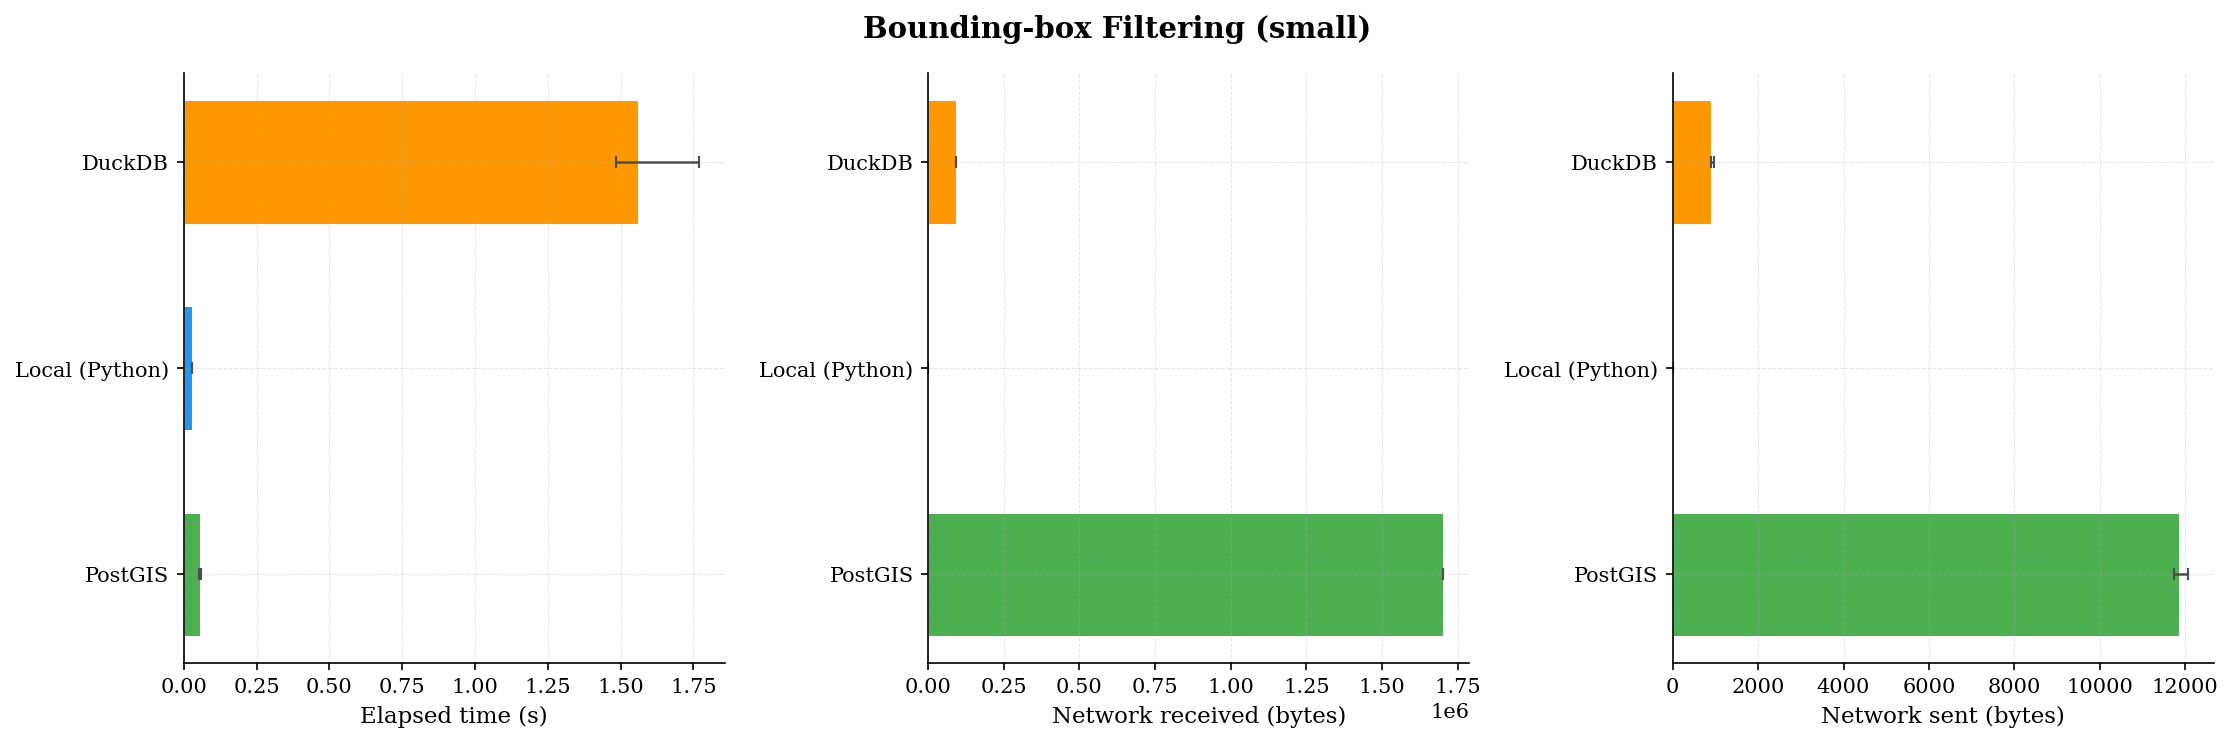

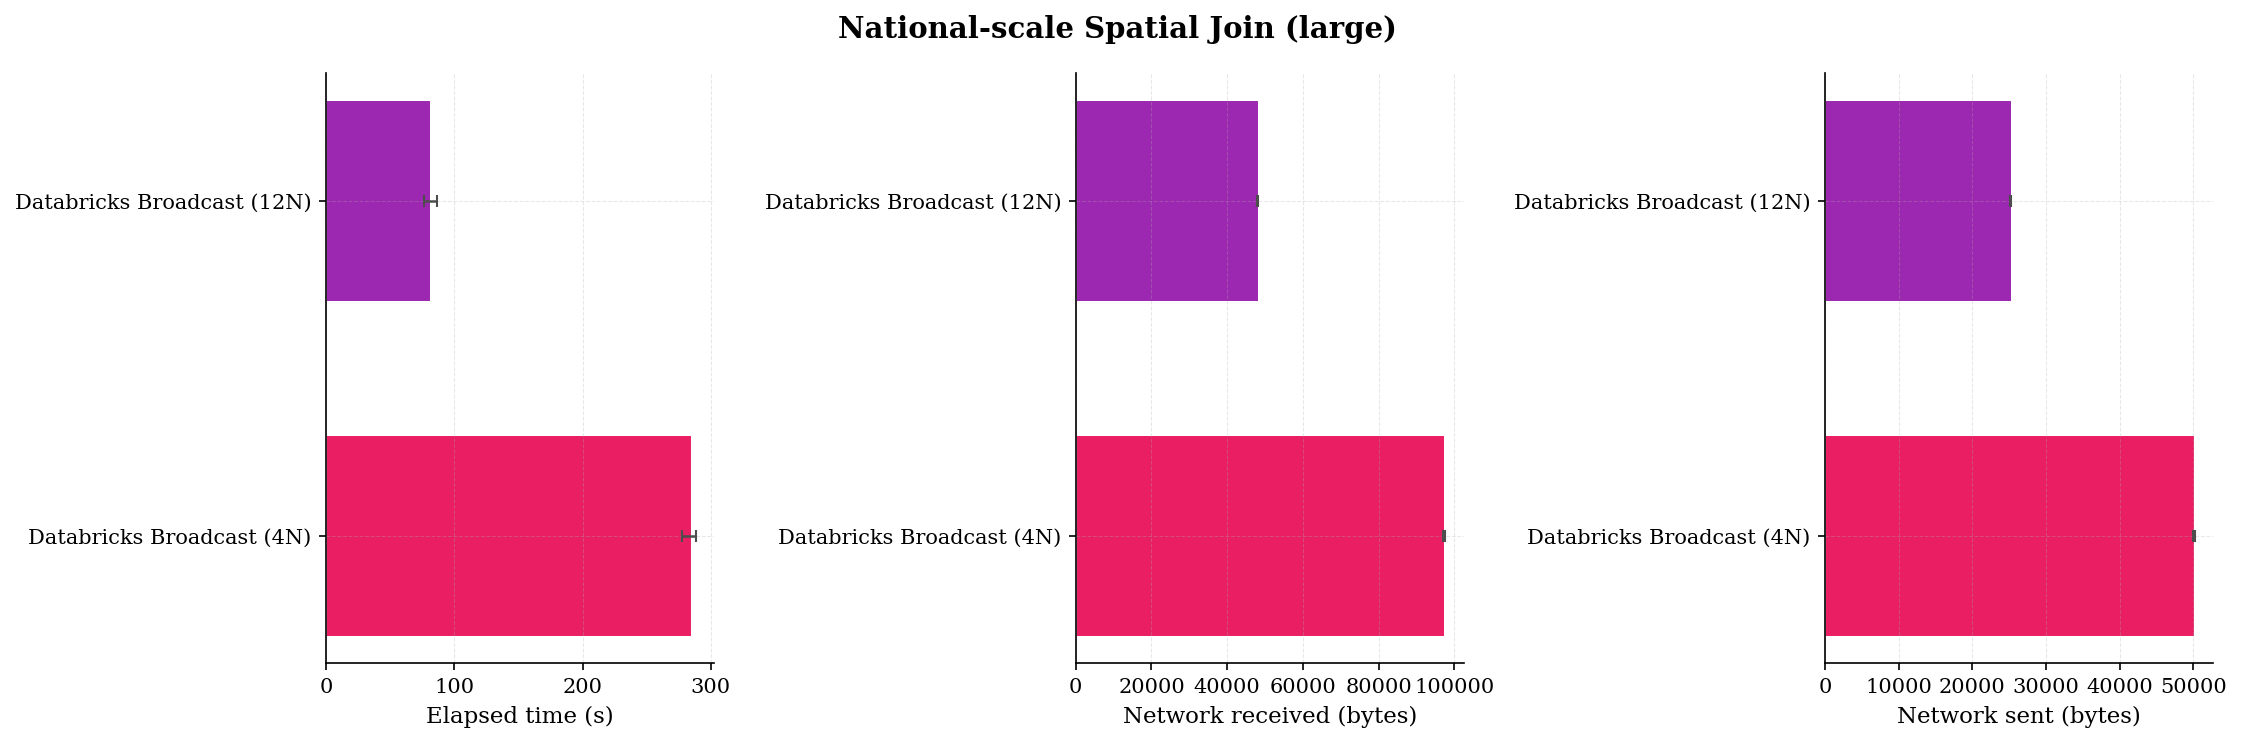

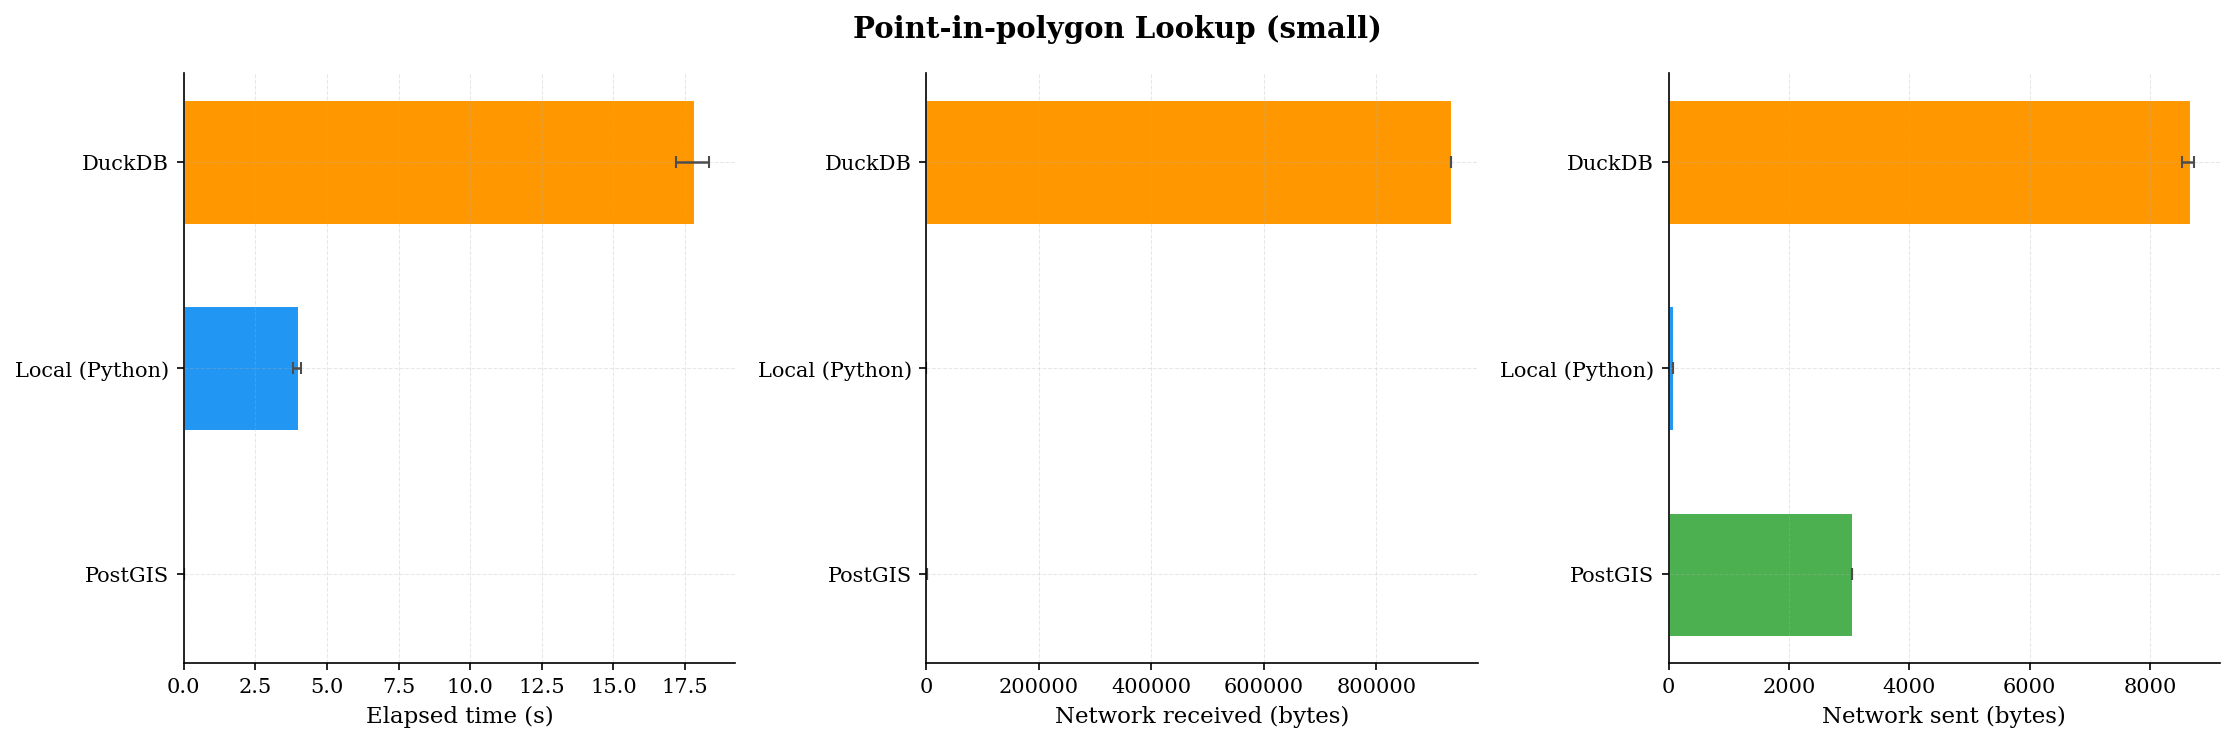

In [21]:
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        configs = sorted(data["configuration"].unique())
        metrics_present = [m for m in PRIMARY_METRICS if data[m].notna().any()]
        n_metrics = len(metrics_present)
        if n_metrics == 0:
            continue

        fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
        if n_metrics == 1:
            axes = [axes]

        for ax, metric in zip(axes, metrics_present):
            medians, ci_lo, ci_hi, colors, labels = [], [], [], [], []
            for cfg in configs:
                vals = data[data["configuration"] == cfg][metric].dropna().values
                if len(vals) == 0:
                    continue
                med = np.median(vals)
                lo, hi = _bootstrap_median_ci(vals)
                medians.append(med)
                ci_lo.append(med - lo)
                ci_hi.append(hi - med)
                colors.append(_color(cfg))
                labels.append(_label(cfg))

            y = np.arange(len(medians))
            ax.barh(y, medians, color=colors, edgecolor="white", linewidth=0.5, height=0.6)
            ax.errorbar(medians, y, xerr=[ci_lo, ci_hi], fmt="none", ecolor="0.3",
                        capsize=3, linewidth=1.2)
            ax.set_yticks(y)
            ax.set_yticklabels(labels)
            ax.set_xlabel(_mlabel(metric))
            ax.invert_yaxis()

        fig.suptitle(f"{_wlabel(wt)} ({ds})", fontsize=14, fontweight="bold")
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_median_bars")

### 9.2 Distribution of Elapsed Time

Violin plots show the full density of each configuration's elapsed-time
distribution. The thick bar marks the interquartile range (IQR) and the
horizontal line marks the median. Wider sections indicate where more
measurements concentrate.

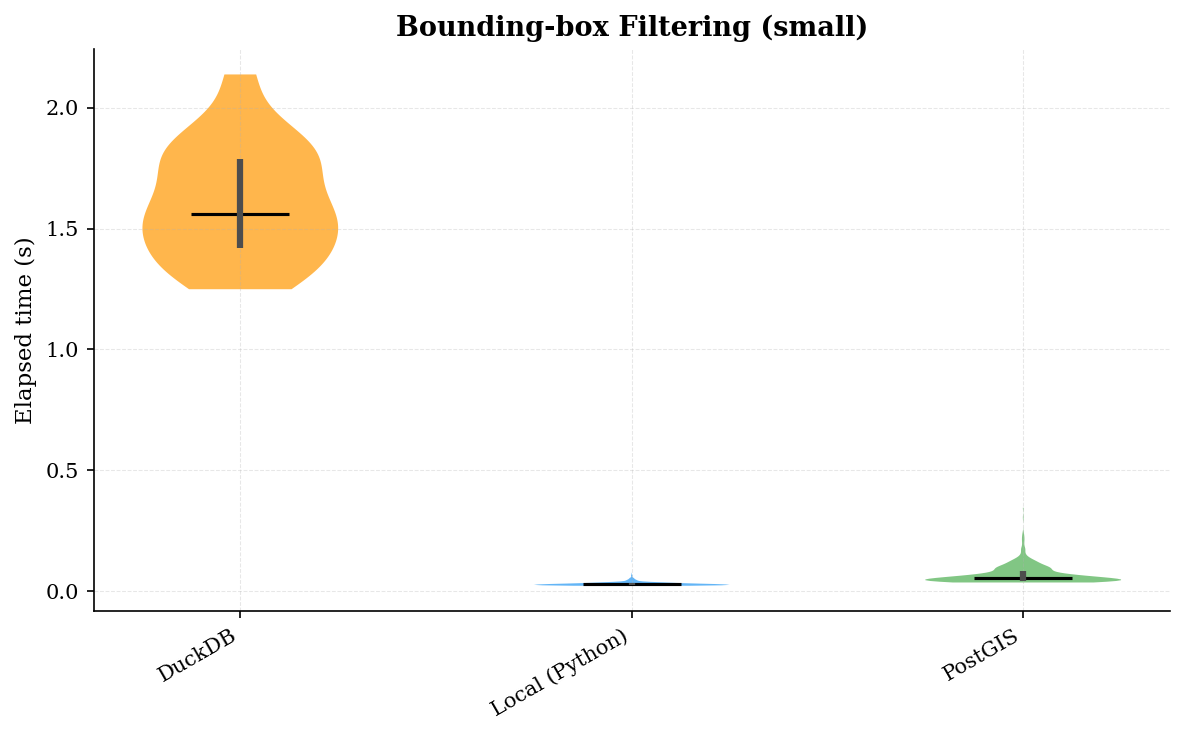

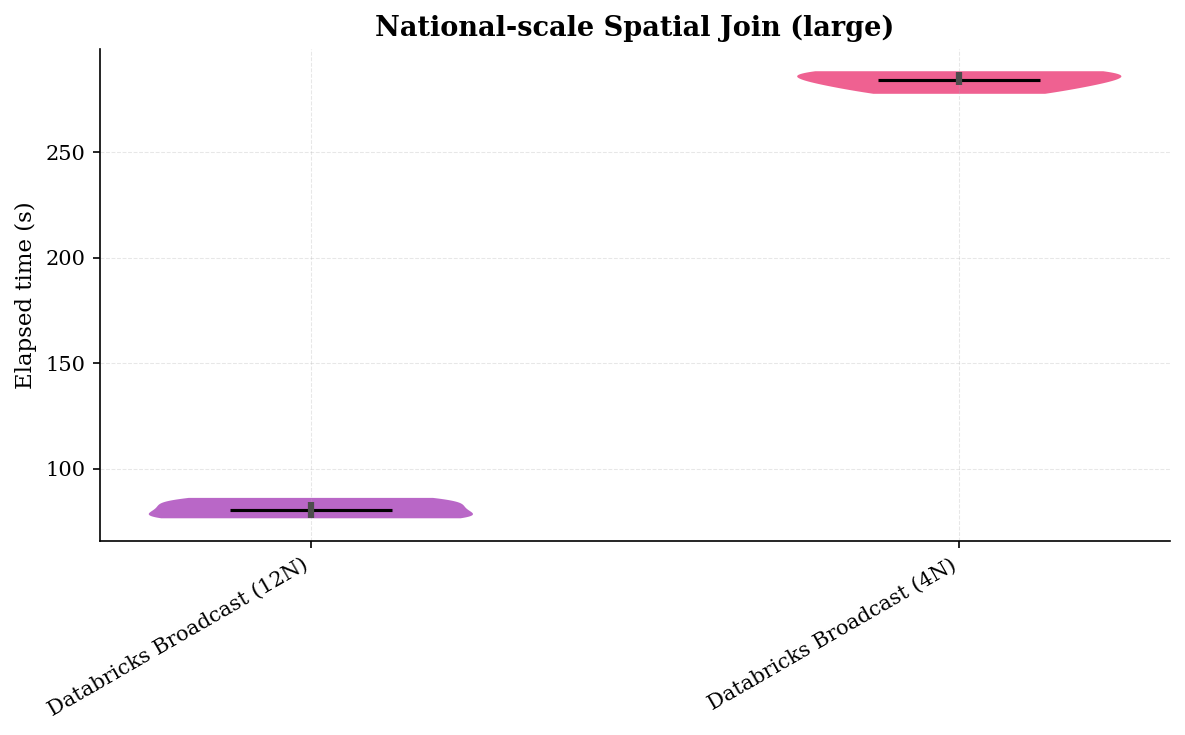

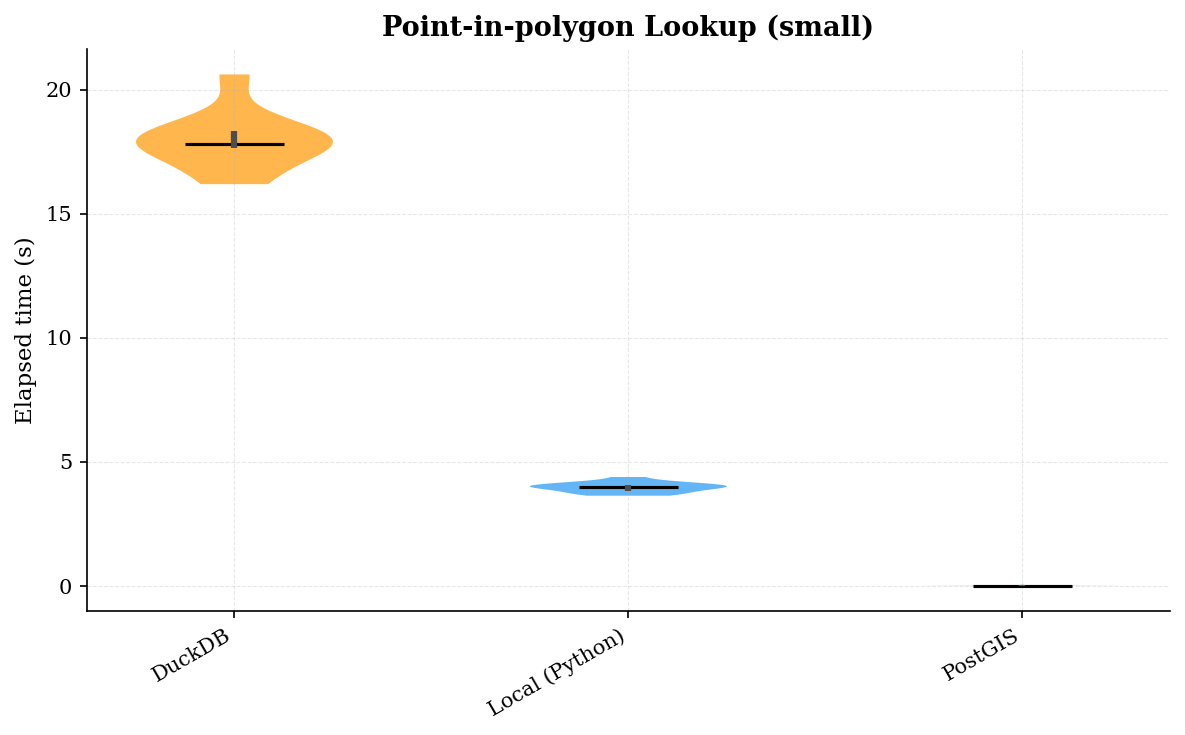

In [22]:
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        configs = sorted(data["configuration"].unique())
        bp_data = [data[data["configuration"] == c]["elapsed_time"].dropna().values for c in configs]
        bp_data = [d for d in bp_data if len(d) > 0]
        configs_present = [c for c, d in zip(configs, [data[data["configuration"] == c]["elapsed_time"].dropna().values for c in configs]) if len(d) > 0]
        if not bp_data:
            continue

        fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(configs_present)), 5))
        parts = ax.violinplot(bp_data, positions=range(len(bp_data)), showmedians=True, showextrema=False)
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(_color(configs_present[i]))
            pc.set_alpha(0.7)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.5)

        q1s = [np.percentile(d, 25) for d in bp_data]
        q3s = [np.percentile(d, 75) for d in bp_data]
        ax.vlines(range(len(bp_data)), q1s, q3s, color="0.3", linewidth=3, zorder=3)

        ax.set_xticks(range(len(configs_present)))
        ax.set_xticklabels([_label(c) for c in configs_present], rotation=30, ha="right")
        ax.set_ylabel(_mlabel("elapsed_time"))
        ax.set_title(f"{_wlabel(wt)} ({ds})")
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_violin")

### 9.3 Iteration Timeseries

Per-iteration elapsed time reveals warm-up effects, cache behaviour, and
temporal drift. Early spikes that settle indicate cold-start overhead.

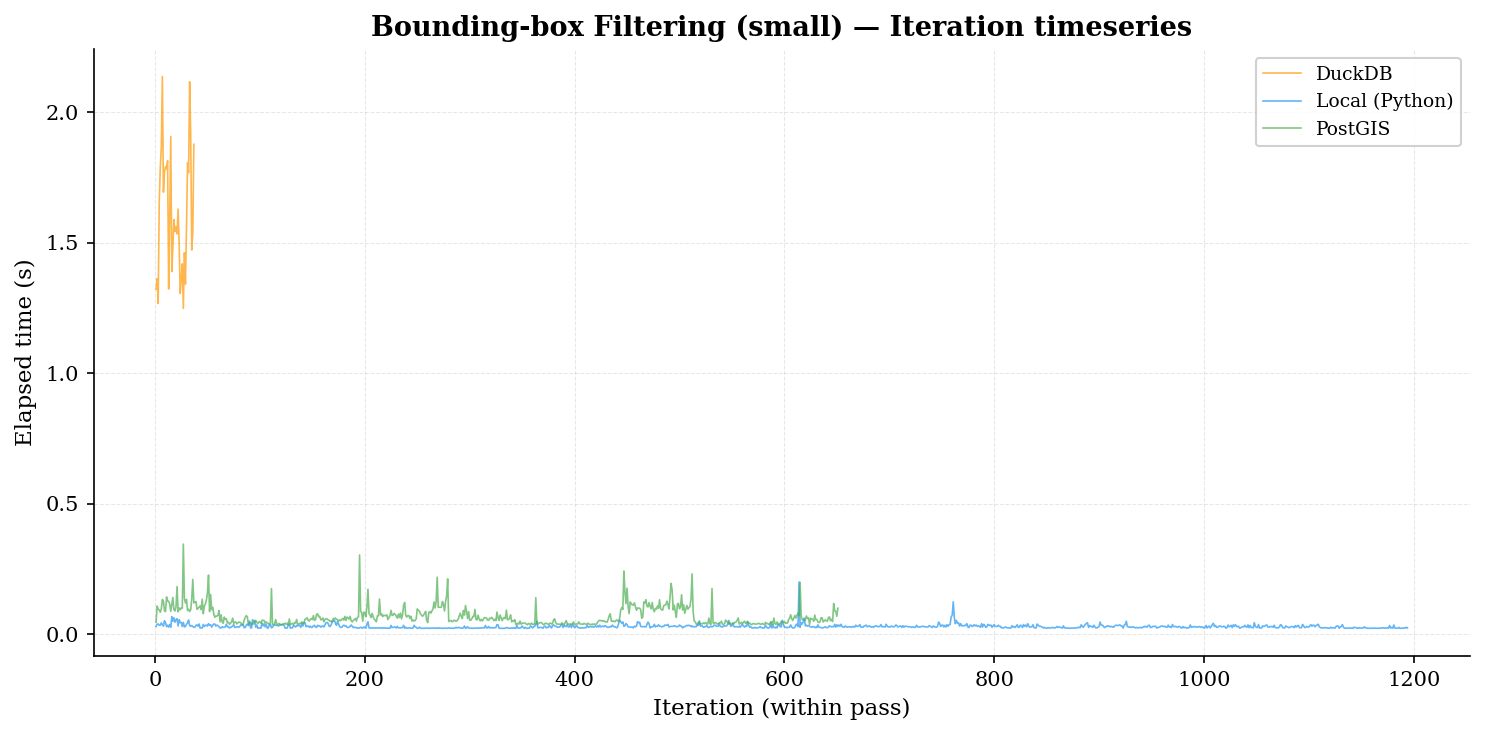

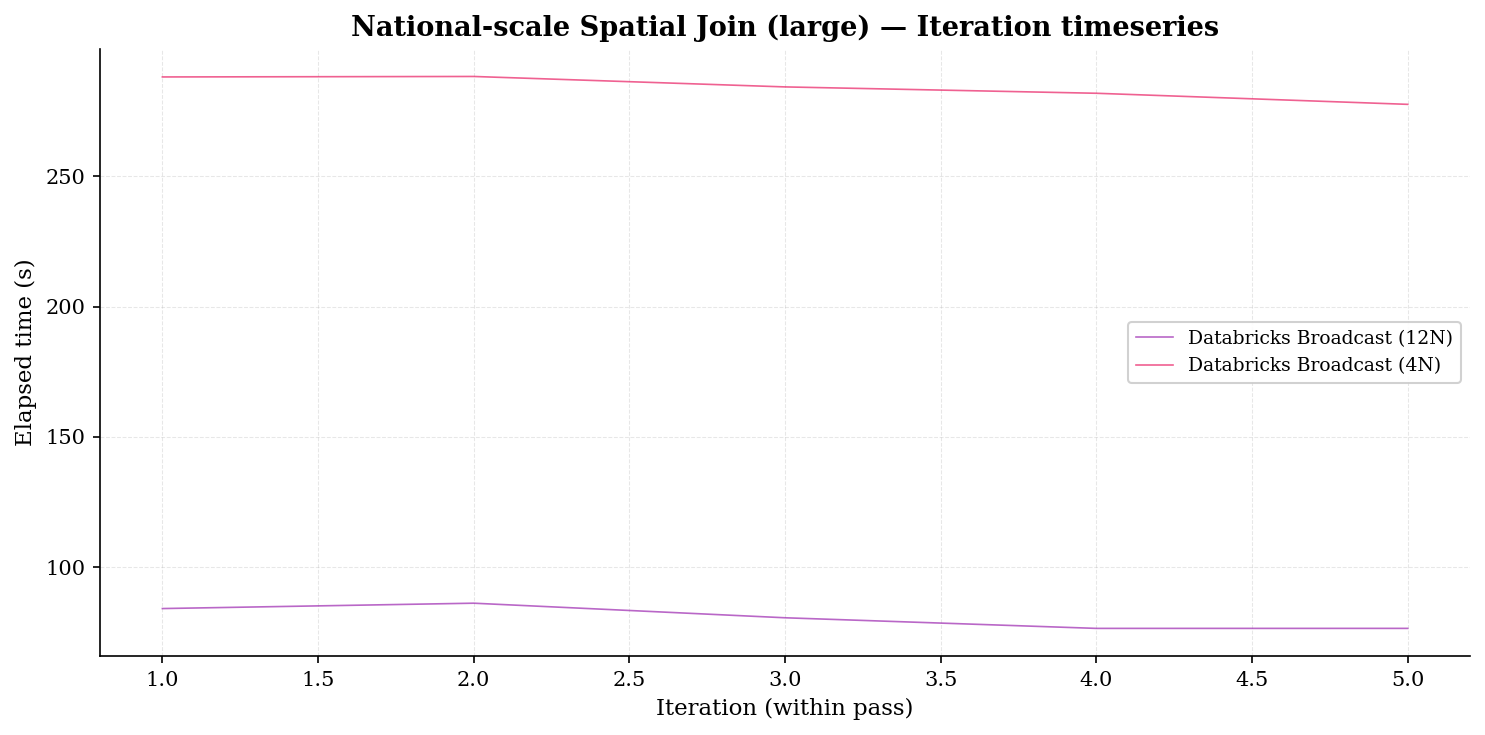

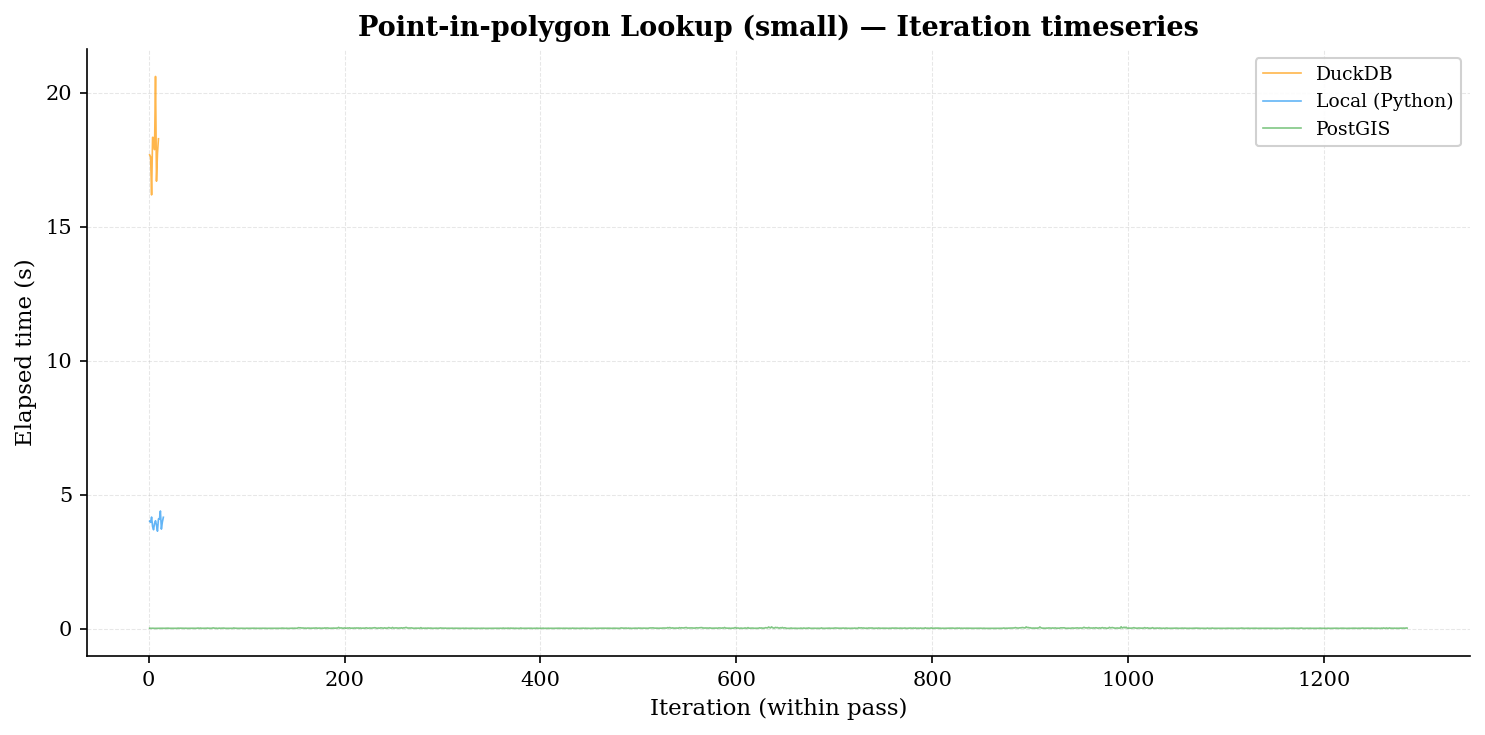

In [23]:
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        configs = sorted(data["configuration"].unique())

        fig, ax = plt.subplots(figsize=(10, 5))
        for cfg in configs:
            d = data[data["configuration"] == cfg].sort_values("local_iteration")
            ax.plot(d["local_iteration"], d["elapsed_time"],
                    label=_label(cfg), color=_color(cfg), alpha=0.7, linewidth=0.8)
        ax.set_xlabel("Iteration (within pass)")
        ax.set_ylabel(_mlabel("elapsed_time"))
        ax.set_title(f"{_wlabel(wt)} ({ds}) — Iteration timeseries")
        ax.legend(loc="best", fontsize=9)
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_timeseries")

### 9.4 Elapsed Time vs Network I/O

Scatter plots expose the relationship between computation time and network
transfer. Configurations that run locally (zero network) cluster along the
x-axis, while client-server solutions (PostGIS, DuckDB) show non-trivial
network traffic.

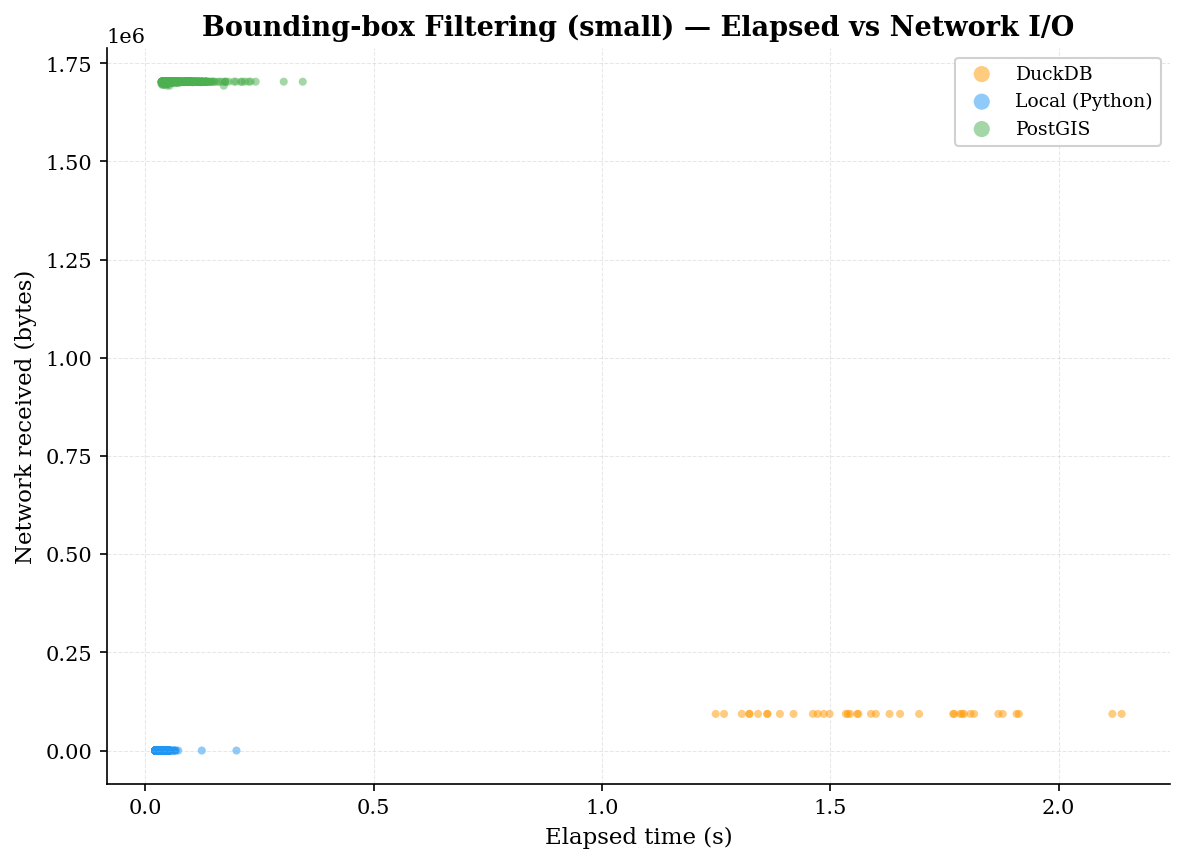

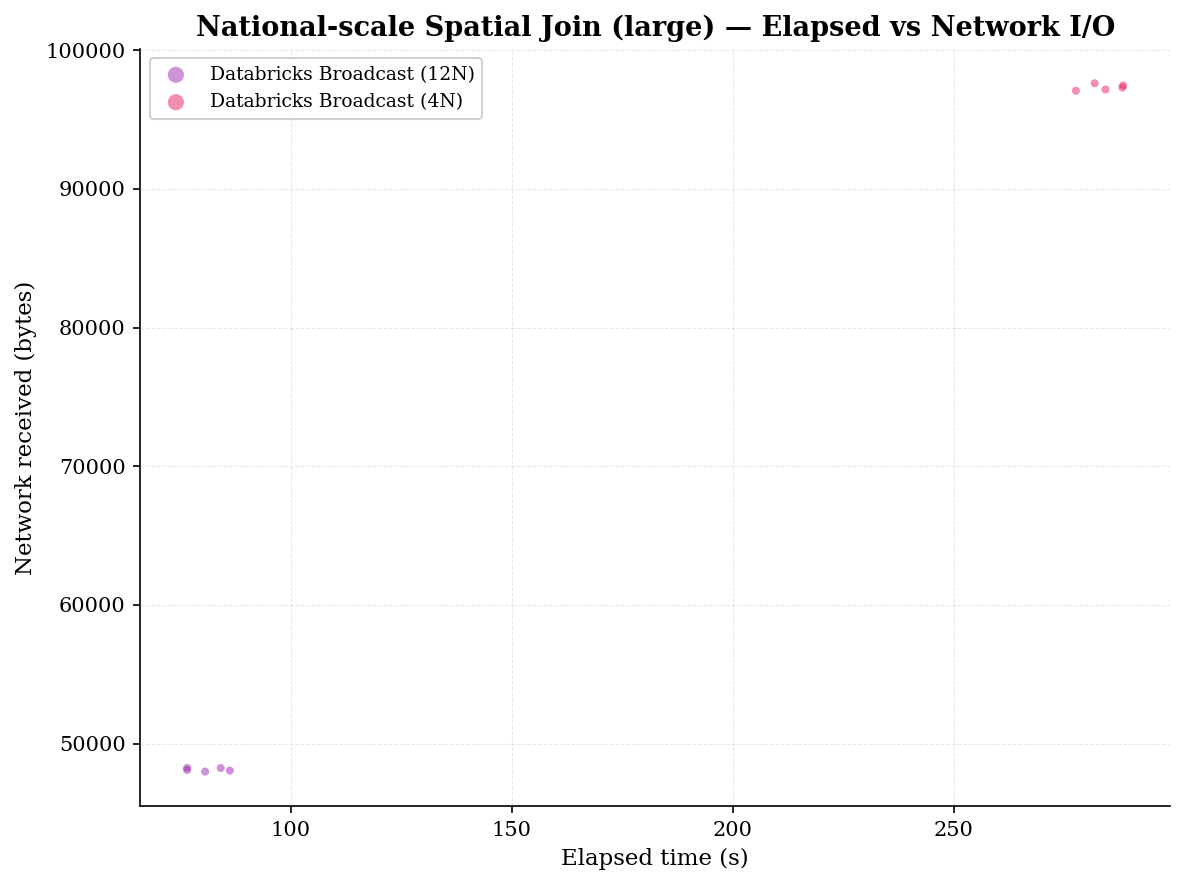

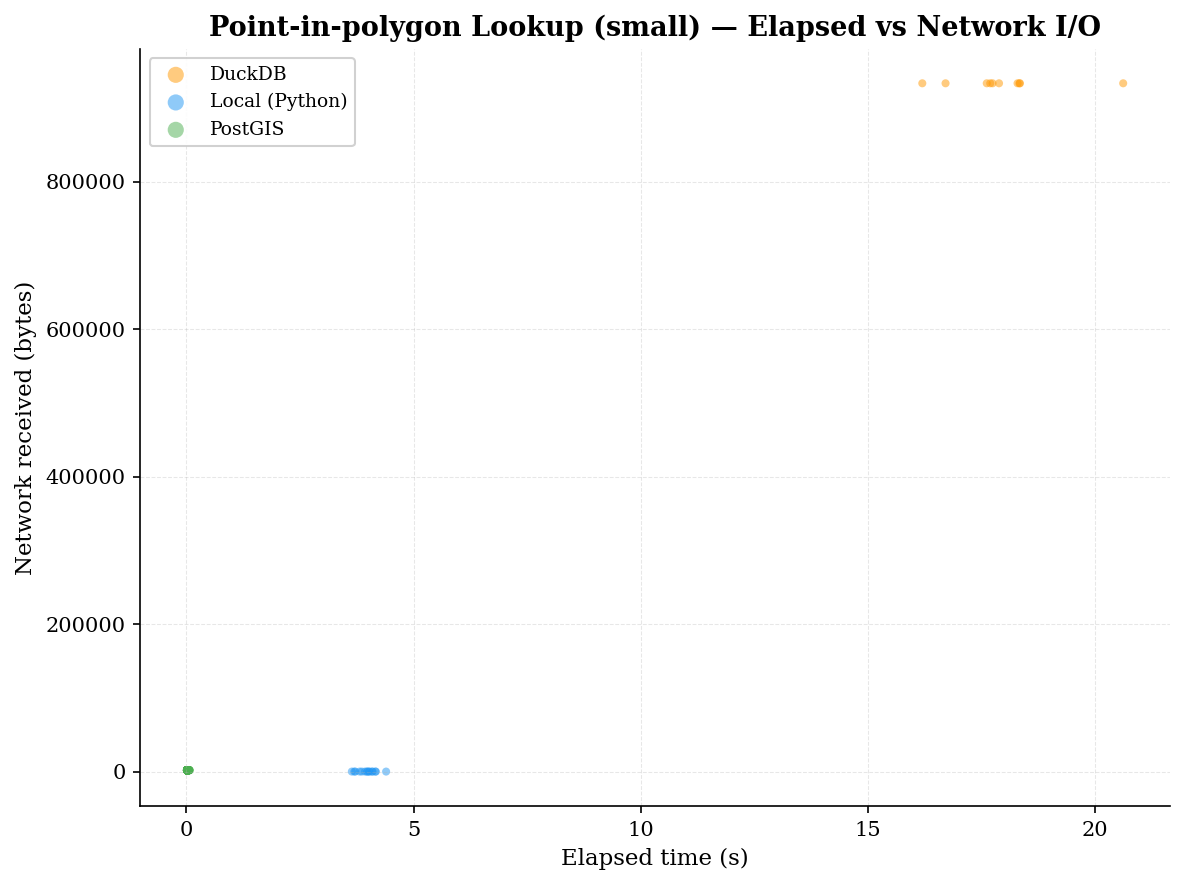

In [24]:
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        configs = sorted(data["configuration"].unique())

        fig, ax = plt.subplots(figsize=(8, 6))
        for cfg in configs:
            d = data[data["configuration"] == cfg]
            ax.scatter(d["elapsed_time"], d["network_bytes_received"],
                       label=_label(cfg), color=_color(cfg), alpha=0.5, s=15, edgecolors="none")
        ax.set_xlabel(_mlabel("elapsed_time"))
        ax.set_ylabel(_mlabel("network_bytes_received"))
        ax.set_title(f"{_wlabel(wt)} ({ds}) — Elapsed vs Network I/O")
        ax.legend(loc="best", fontsize=9, markerscale=2)
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_scatter")

### 9.5 CPU Time Breakdown

Stacked bars show median user (coloured) and system (grey) CPU time per
iteration. PostGIS and Databricks show near-zero *client-side* CPU because
computation runs on the server; the metric captures only the benchmark
harness overhead.

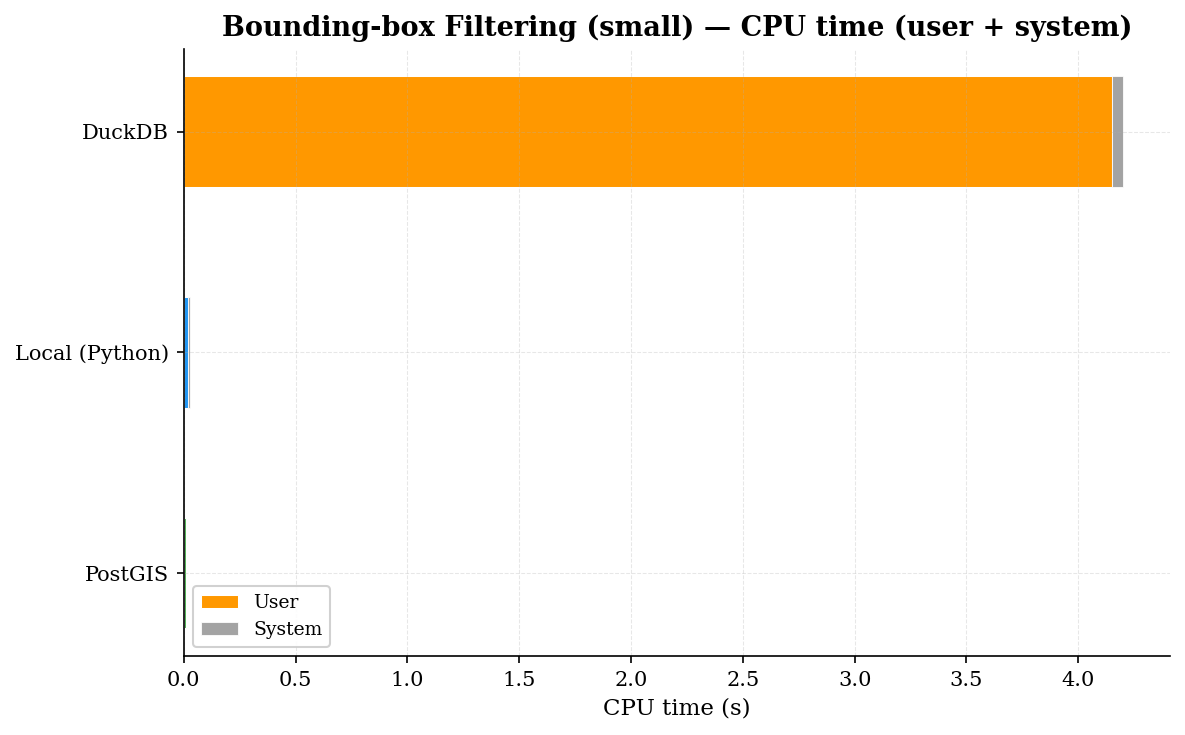

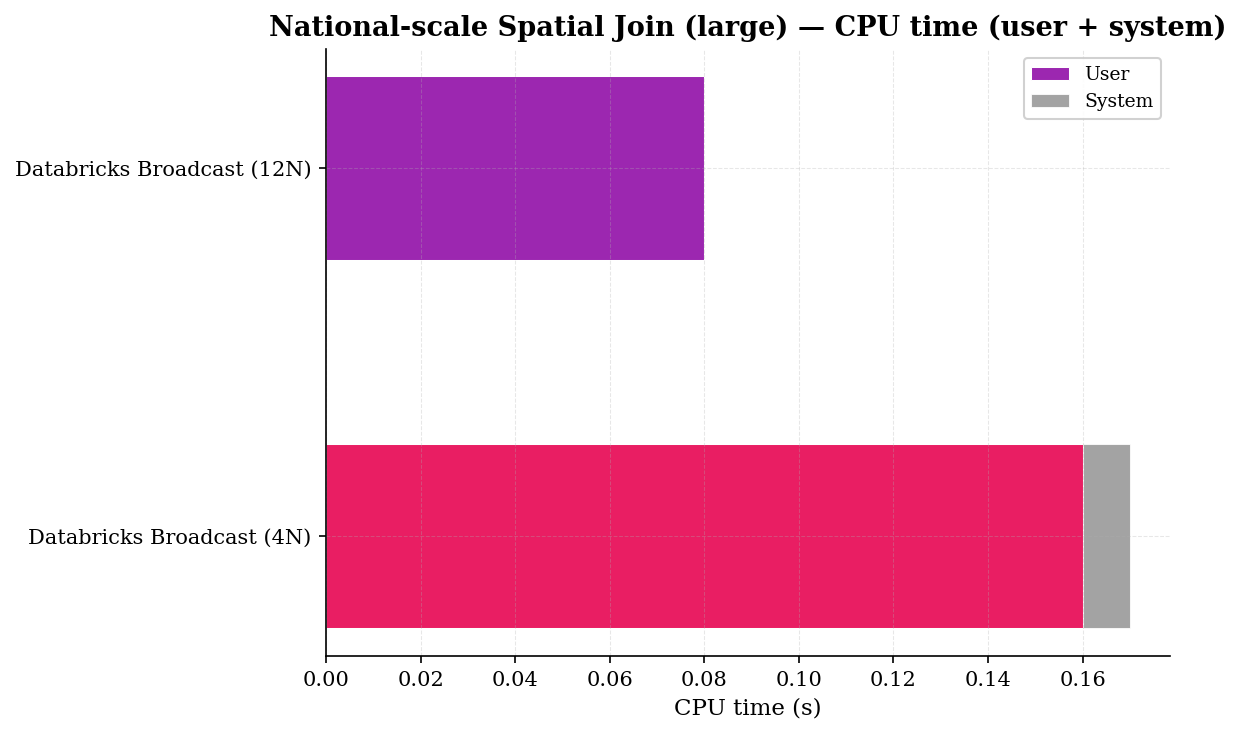

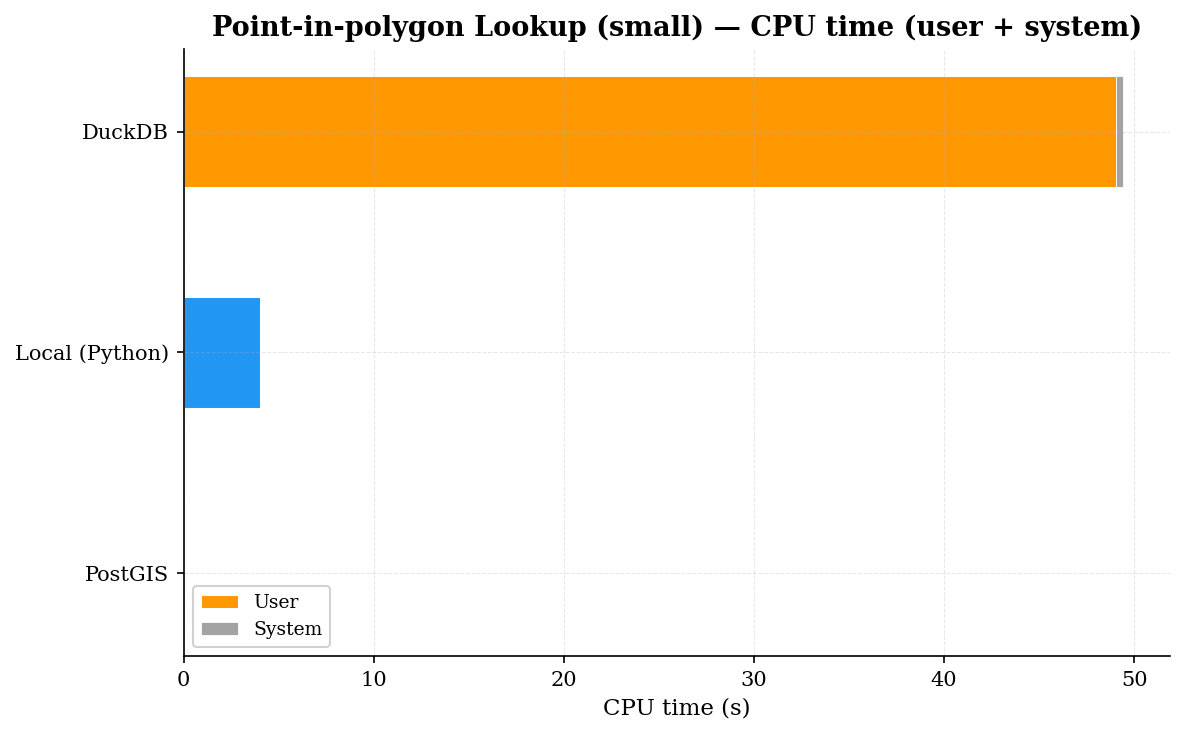

In [25]:
cpu_metrics = ["cpu_time_user_seconds", "cpu_time_system_seconds"]
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        has_cpu = all(data[m].notna().any() for m in cpu_metrics)
        if not has_cpu:
            continue

        configs = sorted(data["configuration"].unique())
        configs_present = [c for c in configs if len(data[data["configuration"] == c]) > 0]

        user_meds = [float(np.median(data[data["configuration"] == c]["cpu_time_user_seconds"].dropna())) for c in configs_present]
        sys_meds = [float(np.median(data[data["configuration"] == c]["cpu_time_system_seconds"].dropna())) for c in configs_present]

        fig, ax = plt.subplots(figsize=(max(8, 2 * len(configs_present)), 5))
        y = np.arange(len(configs_present))
        ax.barh(y, user_meds, height=0.5, color=[_color(c) for c in configs_present],
                edgecolor="white", linewidth=0.5, label="User")
        ax.barh(y, sys_meds, height=0.5, left=user_meds,
                color="0.55", edgecolor="white", linewidth=0.5, alpha=0.8, label="System")
        ax.set_yticks(y)
        ax.set_yticklabels([_label(c) for c in configs_present])
        ax.set_xlabel("CPU time (s)")
        ax.set_title(f"{_wlabel(wt)} ({ds}) — CPU time (user + system)")
        ax.legend(loc="best", fontsize=9)
        ax.invert_yaxis()
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_cpu")

### 9.6 Network I/O Distribution

Box plots of bytes received and sent per iteration. A symlog scale is used
when the range exceeds 100x, so that both zero-traffic (local) and
high-traffic (PostGIS) configurations remain visible.

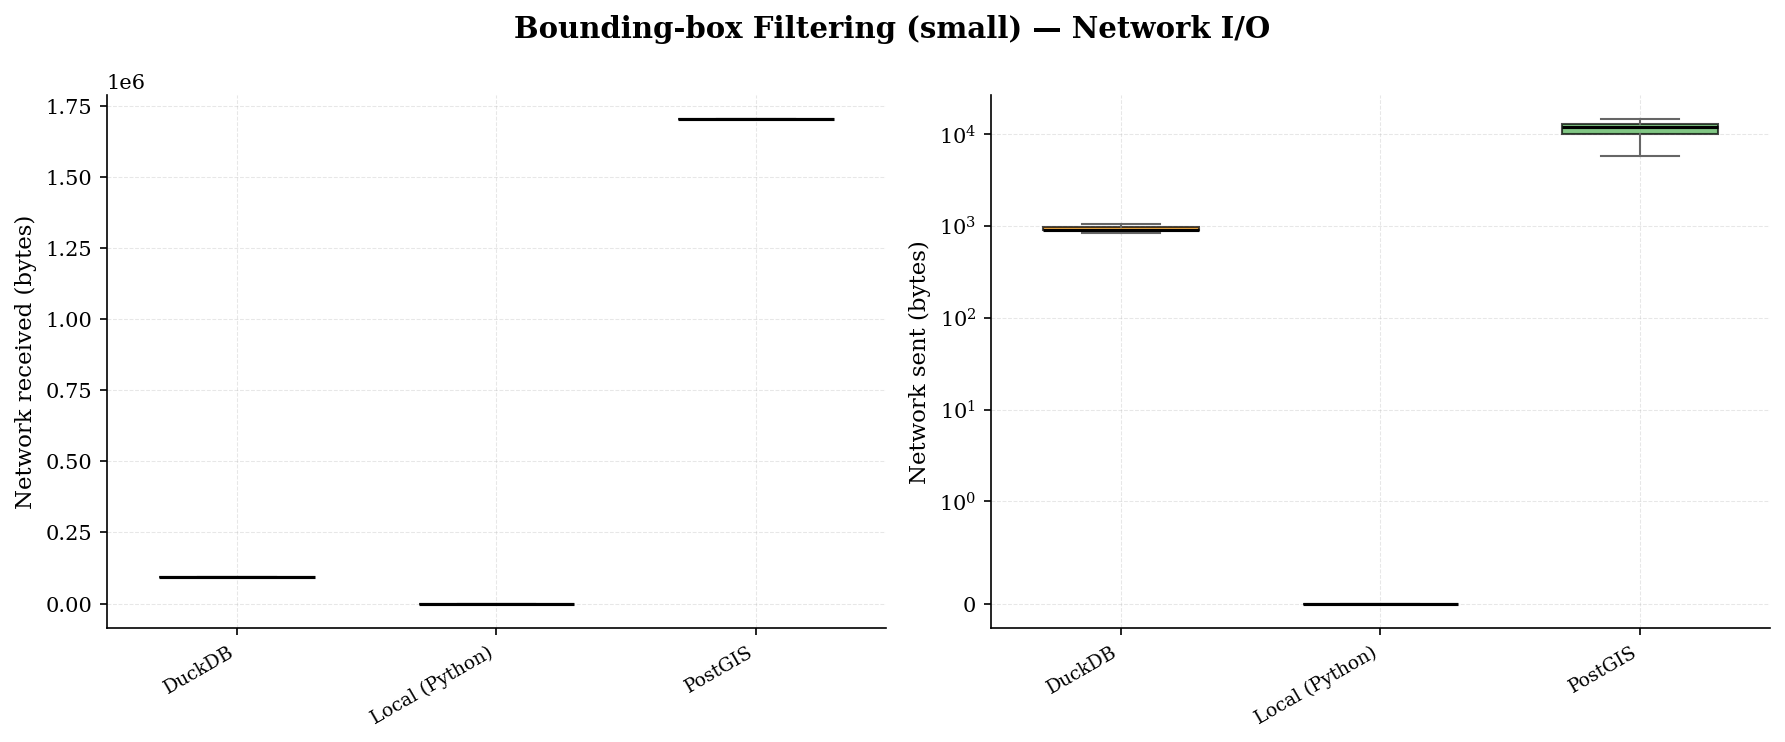

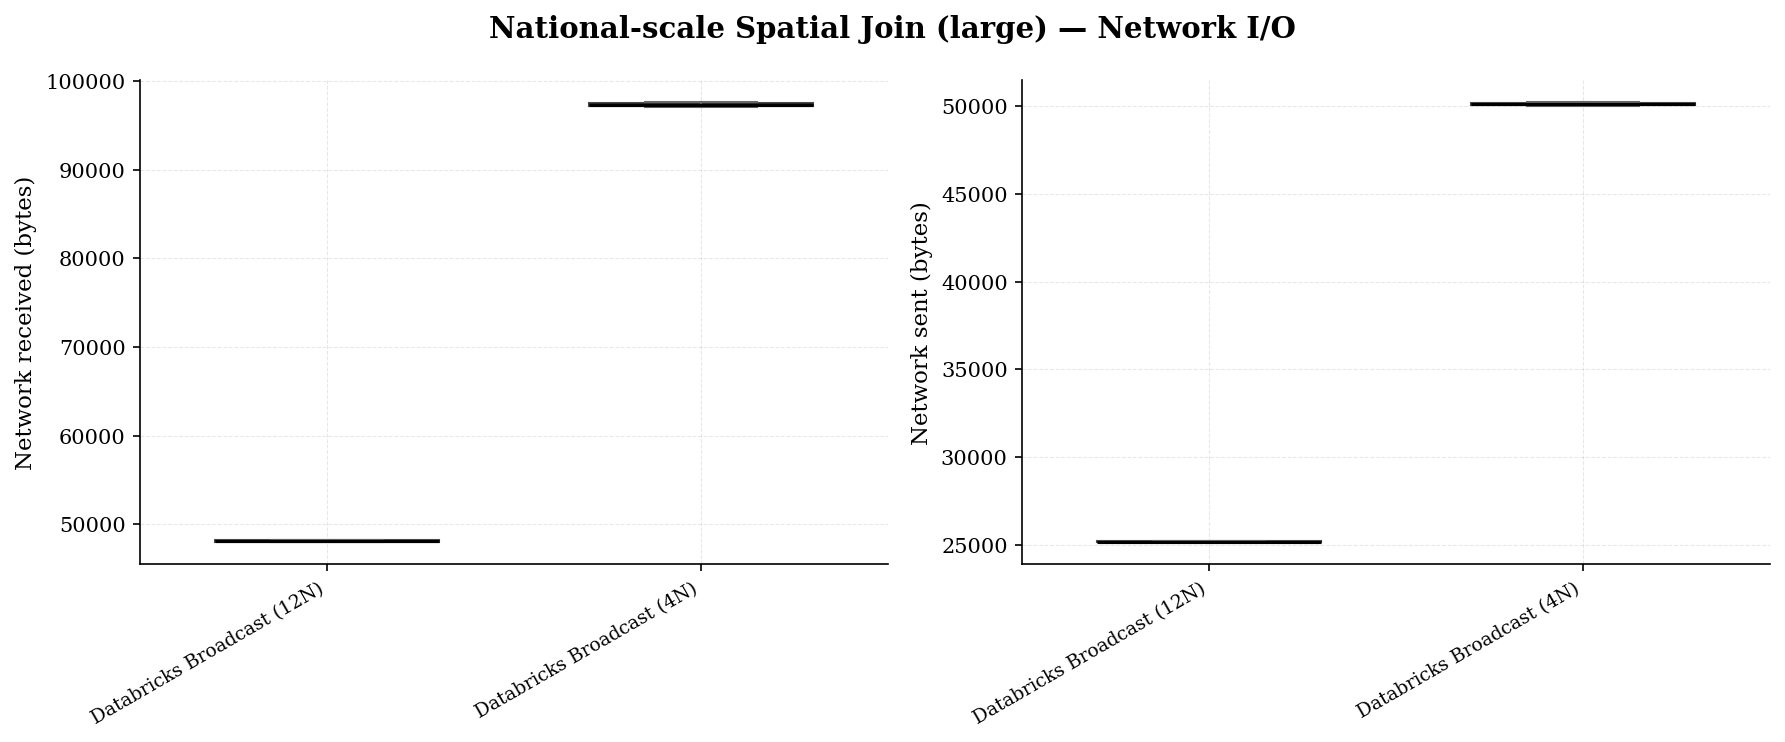

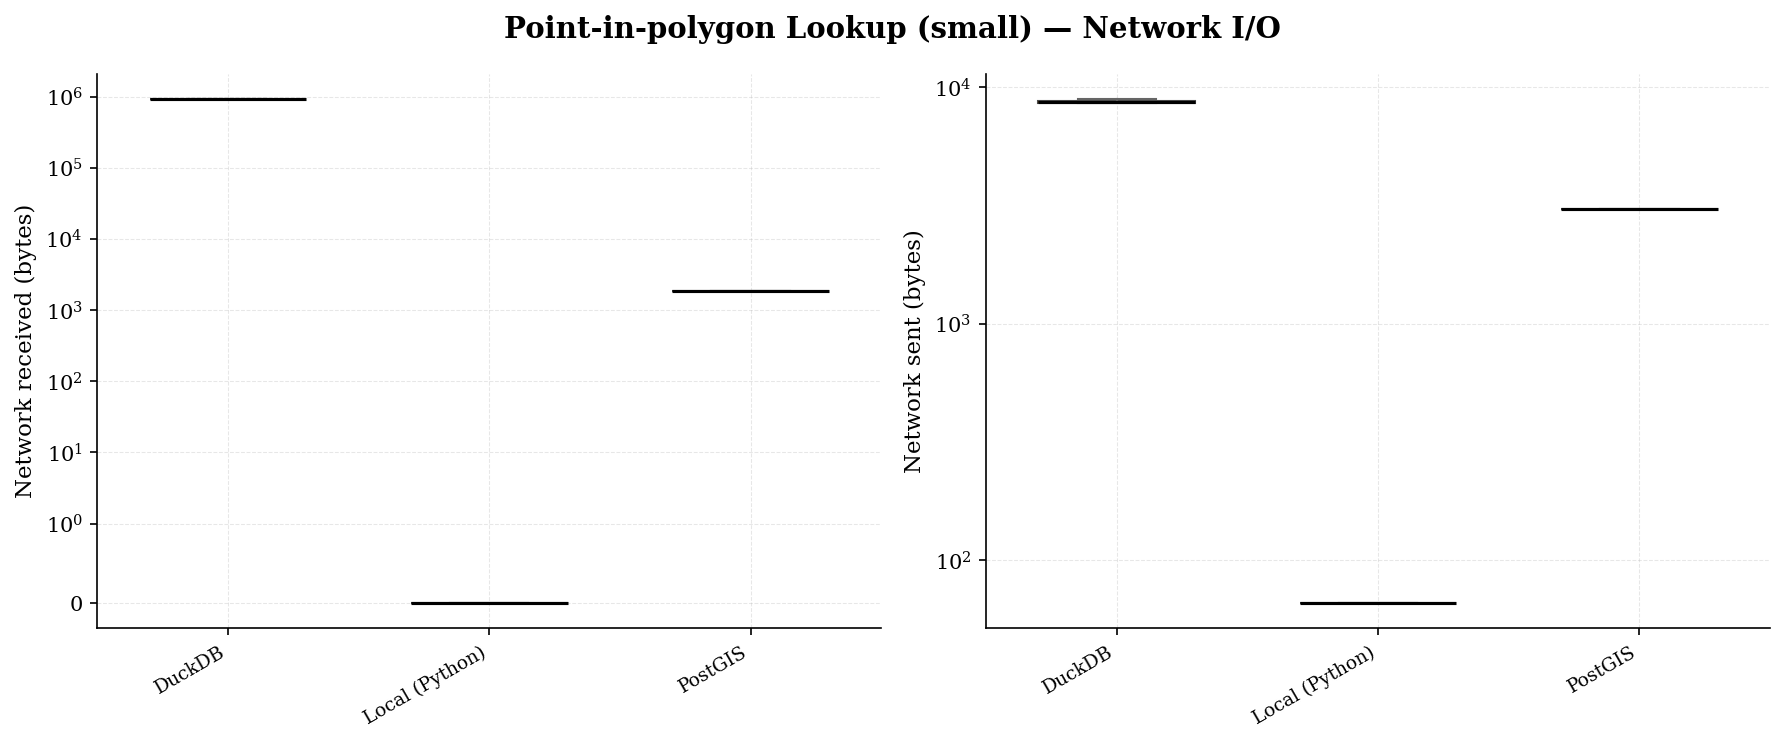

In [26]:
net_metrics = ["network_bytes_received", "network_bytes_sent"]
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        configs = sorted(data["configuration"].unique())
        configs_present = [c for c in configs if len(data[data["configuration"] == c]) > 0]

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, metric in zip(axes, net_metrics):
            bp_data, bp_colors, bp_labels = [], [], []
            for cfg in configs_present:
                vals = data[data["configuration"] == cfg][metric].dropna().values
                if len(vals) > 0:
                    bp_data.append(vals)
                    bp_colors.append(_color(cfg))
                    bp_labels.append(_label(cfg))

            if not bp_data:
                continue

            all_vals = np.concatenate(bp_data)
            pos_vals = all_vals[all_vals > 0]
            use_log = len(pos_vals) > 0 and (pos_vals.max() / pos_vals.min() > 100)

            bplot = ax.boxplot(bp_data, patch_artist=True, showfliers=False, widths=0.6)
            for patch, color in zip(bplot["boxes"], bp_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            for element in ["whiskers", "caps"]:
                for line in bplot[element]:
                    line.set_color("0.4")
            for med in bplot["medians"]:
                med.set_color("black")
                med.set_linewidth(1.5)

            if use_log:
                ax.set_yscale("symlog", linthresh=1)

            ax.set_xticklabels(bp_labels, rotation=30, ha="right", fontsize=9)
            ax.set_ylabel(_mlabel(metric))

        fig.suptitle(f"{_wlabel(wt)} ({ds}) — Network I/O", fontsize=14, fontweight="bold")
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_network")

### 9.7 Scaling Curve (RQ2)

Elapsed time vs. worker count for distributed Databricks joins.  Error bars
show the range across benchmark passes.  Dashed lines mark single-node
baselines where available.

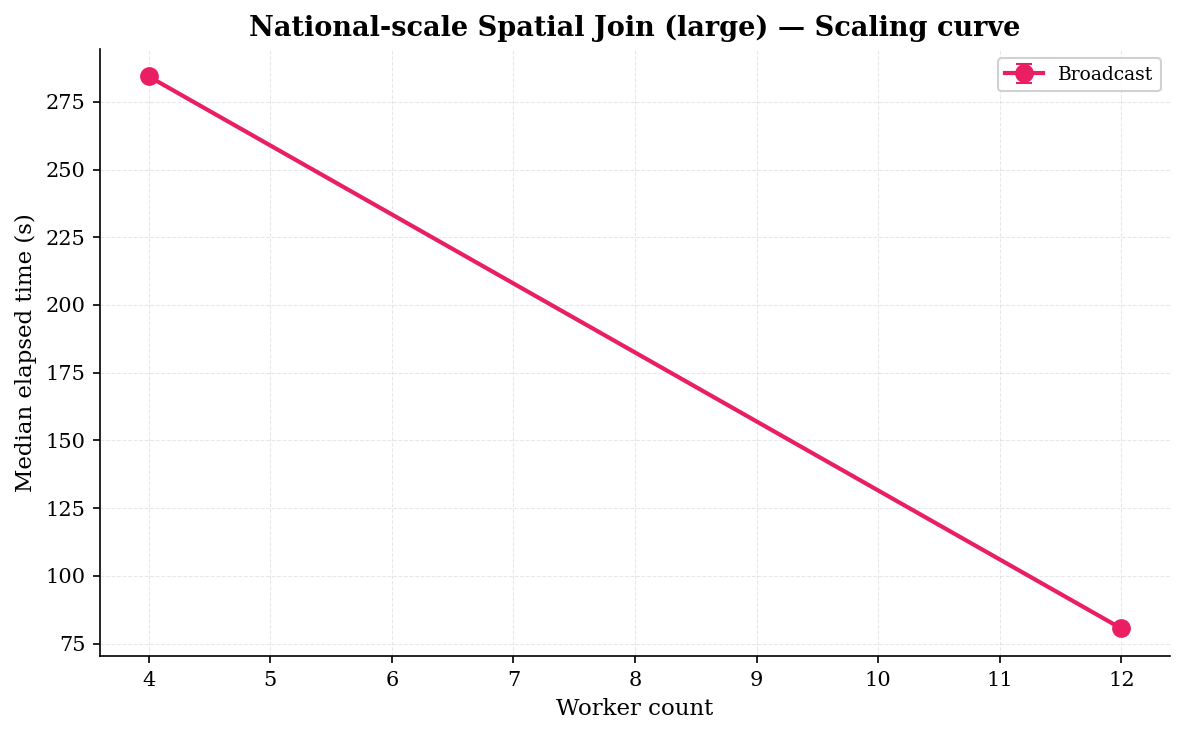

In [27]:
strategy_colors = {"broadcast": "#E91E63", "partitioned": "#00BCD4", "default": "#607D8B"}

if len(rq2_scaling) > 0:
    for ds in rq2_scaling["dataset_size"].unique():
        ds_data = rq2_scaling[rq2_scaling["dataset_size"] == ds]
        if ds_data.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 5))
        for strategy in sorted(ds_data["strategy"].unique()):
            s = ds_data[ds_data["strategy"] == strategy].sort_values("worker_count")
            col = strategy_colors.get(strategy, "#999")
            ax.errorbar(
                s["worker_count"], s["headline_median"],
                yerr=[s["headline_median"] - s["pass_min"], s["pass_max"] - s["headline_median"]],
                marker="o", label=strategy.capitalize(), color=col, capsize=4,
                linewidth=2, markersize=8,
            )

        if "dataset_size" in rq2_single_node.columns:
            sn = rq2_single_node[rq2_single_node["dataset_size"] == ds]
            for _, row in sn.iterrows():
                ax.axhline(y=row["headline_median"], linestyle="--", alpha=0.6,
                           color=_color(row["configuration"]), linewidth=1.5,
                           label=_label(row["configuration"]))

        ax.set_xlabel("Worker count")
        ax.set_ylabel("Median elapsed time (s)")
        ax.set_title(f"National-scale Spatial Join ({ds}) — Scaling curve")
        ax.legend(loc="best", fontsize=9)
        fig.tight_layout()
        _savefig(fig, f"scaling_curve_{ds}")
else:
    print("No scaling data to plot")

### 9.8 Cross-workload Comparison (RQ3)

Grouped bars compare the same configurations across different workload types.
Log scale is used so that sub-second results (PostGIS bbox-filtering) and
multi-second results (DuckDB point-in-polygon) are both readable.  Value
labels are printed above each bar.

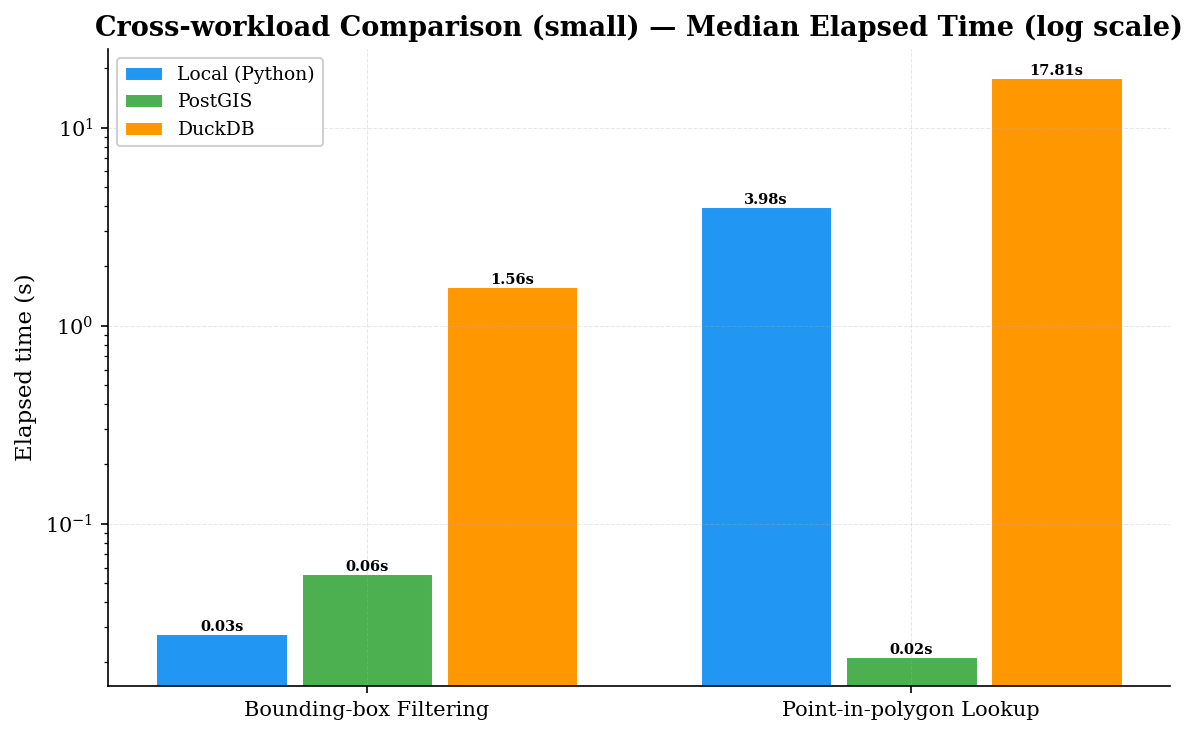

In [28]:
rq1_wts = [wt for wt in ["bbox-filtering", "point-in-polygon-lookup", "knn-search"]
           if wt in successful["workload_type"].unique()]
rq1_configs = ["local", "postgis", "duckdb"]
rq1_configs_present = [c for c in rq1_configs if c in successful["configuration"].unique()]

if len(rq1_wts) >= 2 and len(rq1_configs_present) >= 2:
    for ds in sorted(successful["dataset_size"].unique()):
        rows = []
        for wt in rq1_wts:
            for cfg in rq1_configs_present:
                mask = (
                    (successful["workload_type"] == wt)
                    & (successful["dataset_size"] == ds)
                    & (successful["configuration"] == cfg)
                )
                vals = successful.loc[mask, "elapsed_time"].dropna().values
                if len(vals) > 0:
                    rows.append({"workload": wt, "config": cfg, "median": float(np.median(vals))})

        if not rows:
            continue

        cw = pd.DataFrame(rows)
        wts_in_data = [wt for wt in rq1_wts if wt in cw["workload"].values]
        cfgs_in_data = [c for c in rq1_configs_present if c in cw["config"].values]

        fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(wts_in_data)), 5))
        x = np.arange(len(wts_in_data))
        width = 0.8 / len(cfgs_in_data)

        for i, cfg in enumerate(cfgs_in_data):
            meds = [float(cw[(cw["workload"] == wt) & (cw["config"] == cfg)]["median"].iloc[0])
                    if len(cw[(cw["workload"] == wt) & (cw["config"] == cfg)]) > 0
                    else 0
                    for wt in wts_in_data]
            offset = (i - len(cfgs_in_data) / 2 + 0.5) * width
            bars = ax.bar(x + offset, meds, width * 0.9, label=_label(cfg), color=_color(cfg),
                          edgecolor="white", linewidth=0.5)
            for bar, med in zip(bars, meds):
                if med > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, med, f"{med:.2f}s",
                            ha="center", va="bottom", fontsize=7, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels([_wlabel(wt) for wt in wts_in_data], fontsize=10)
        ax.set_ylabel(_mlabel("elapsed_time"))
        ax.set_yscale("log")
        ax.set_title(f"Cross-workload Comparison ({ds}) — Median Elapsed Time (log scale)")
        ax.legend(loc="best", fontsize=9)
        fig.tight_layout()
        _savefig(fig, f"cross_workload_{ds}")
else:
    print("Not enough RQ1 workloads or configs for cross-workload comparison")

### 9.9 Databricks Internal Metrics

Executor run time, shuffle I/O, and driver collection time reported by the
Spark runtime.  These metrics complement the wall-clock elapsed time and
help explain *why* one strategy scales better than another.

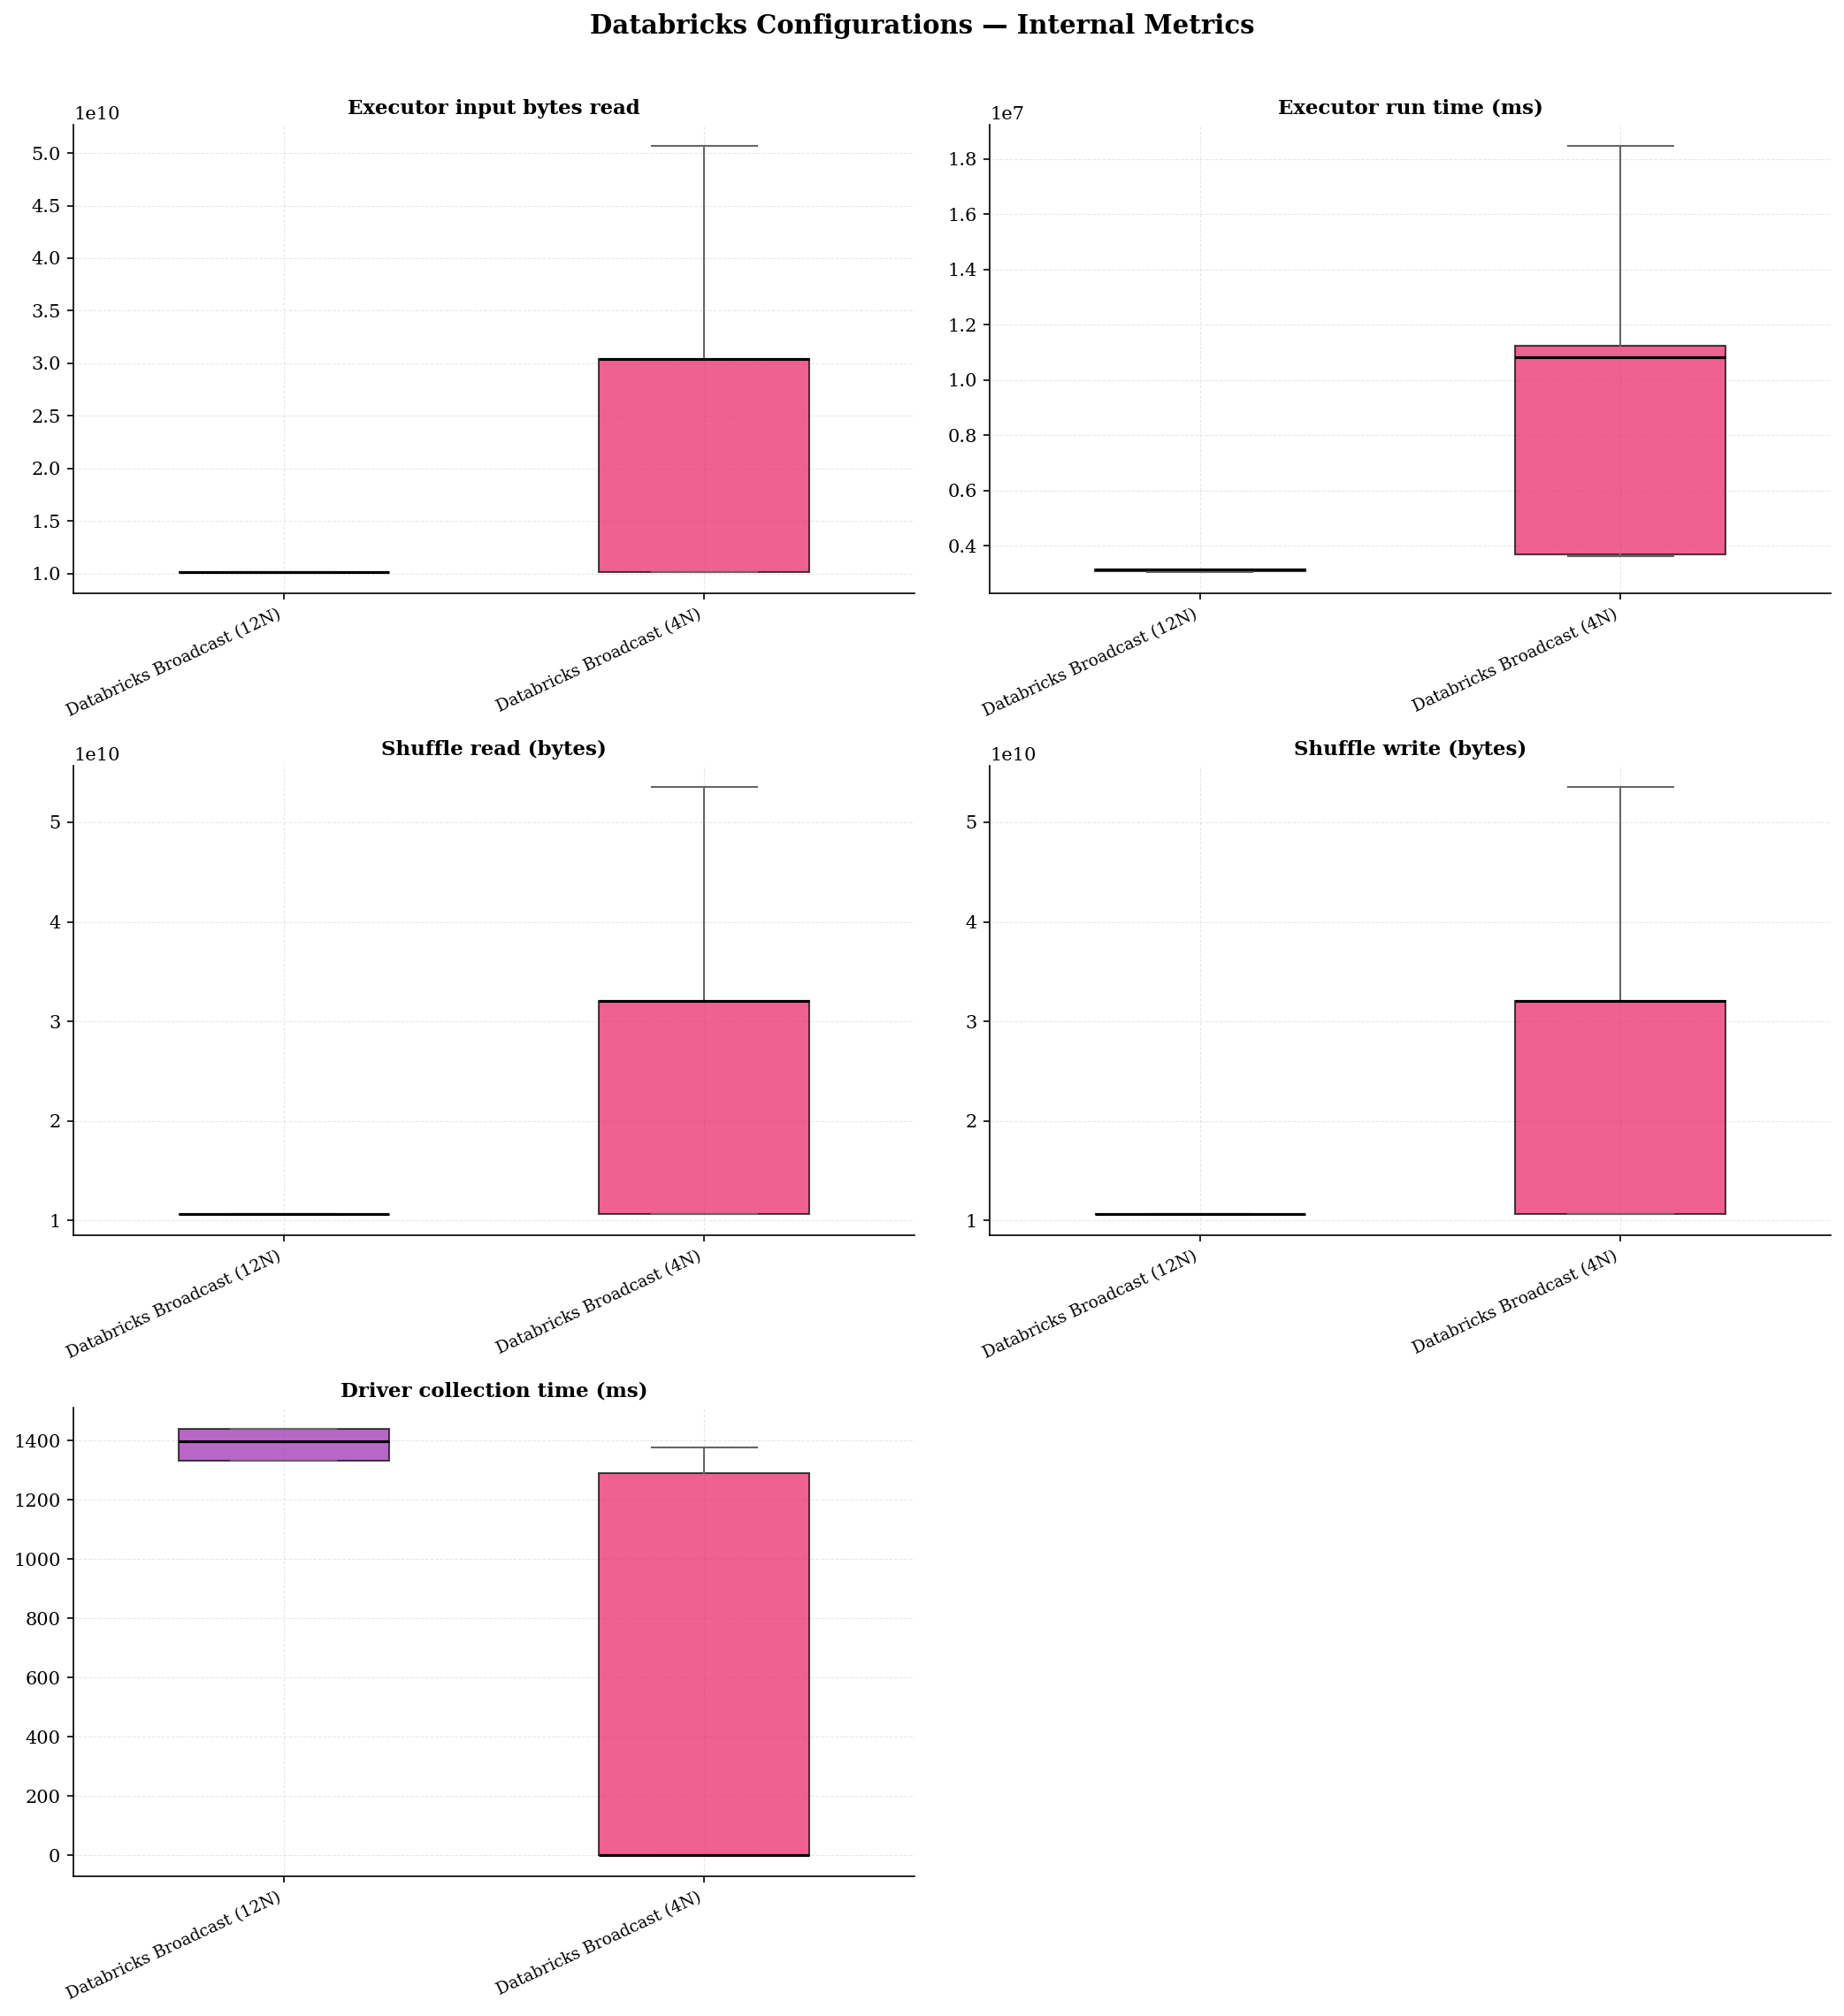

In [29]:
dbr_configs = [c for c in sorted(successful["configuration"].unique()) if "databricks" in c]
dbr_metrics_present = [m for m in DATABRICKS_METRICS if successful[m].notna().any()]

if dbr_configs and dbr_metrics_present:
    dbr_data = successful[successful["configuration"].isin(dbr_configs)]

    n_metrics = len(dbr_metrics_present)
    n_cols = min(2, n_metrics)
    n_rows = (n_metrics + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes_flat = np.atleast_1d(axes).flatten()

    for i, metric in enumerate(dbr_metrics_present):
        ax = axes_flat[i]
        bp_data, bp_colors, bp_labels = [], [], []
        for cfg in dbr_configs:
            vals = dbr_data[dbr_data["configuration"] == cfg][metric].dropna().values
            if len(vals) > 0:
                bp_data.append(vals)
                bp_colors.append(_color(cfg))
                bp_labels.append(_label(cfg))

        if bp_data:
            bplot = ax.boxplot(bp_data, patch_artist=True, showfliers=False, widths=0.5)
            for patch, color in zip(bplot["boxes"], bp_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            for element in ["whiskers", "caps"]:
                for line in bplot[element]:
                    line.set_color("0.4")
            for med in bplot["medians"]:
                med.set_color("black")
                med.set_linewidth(1.5)

        ax.set_xticklabels(bp_labels, rotation=25, ha="right", fontsize=9)
        ax.set_title(_mlabel(metric), fontsize=11, fontweight="bold")
        ax.set_ylabel("")

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle("Databricks Configurations — Internal Metrics", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    _savefig(fig, "databricks_metrics")
else:
    print("No Databricks-specific metrics to plot")

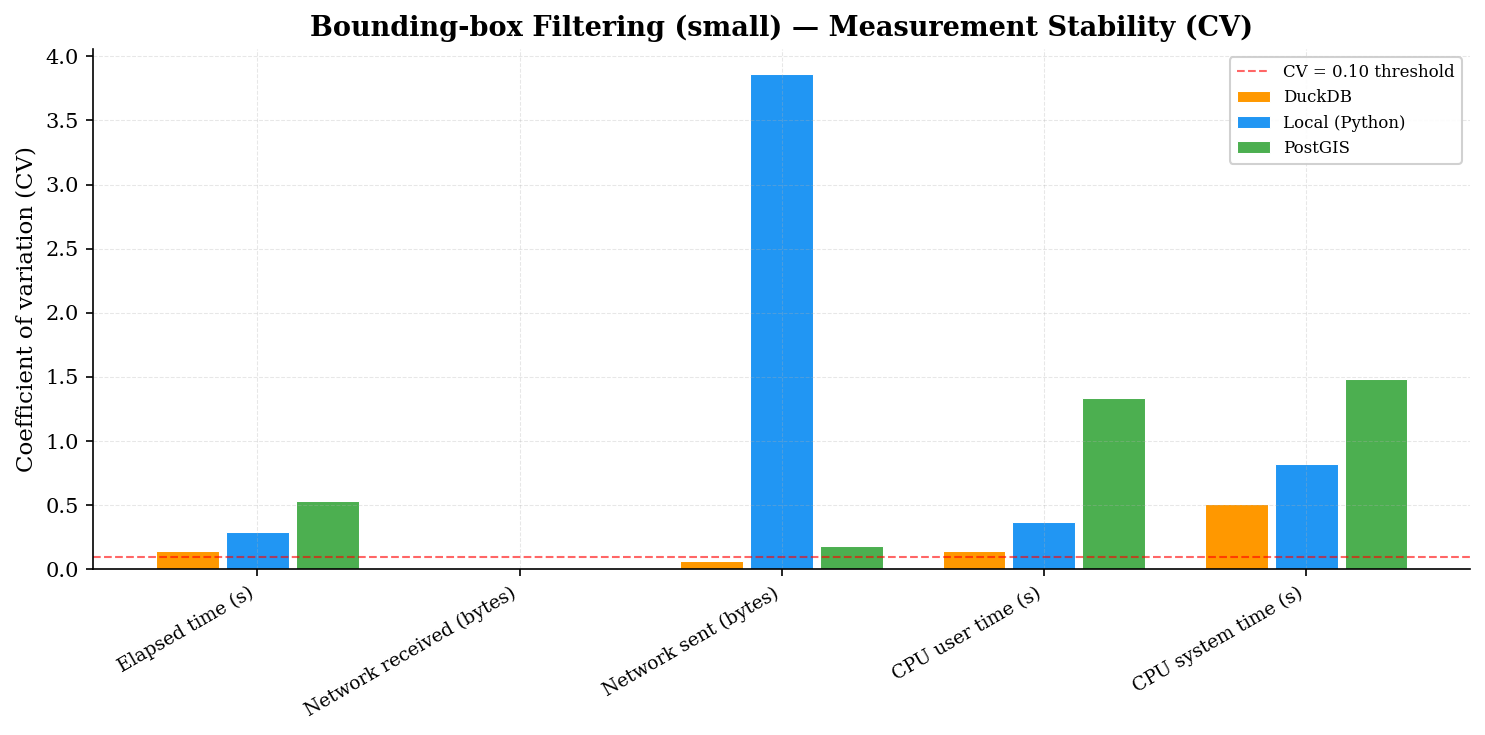

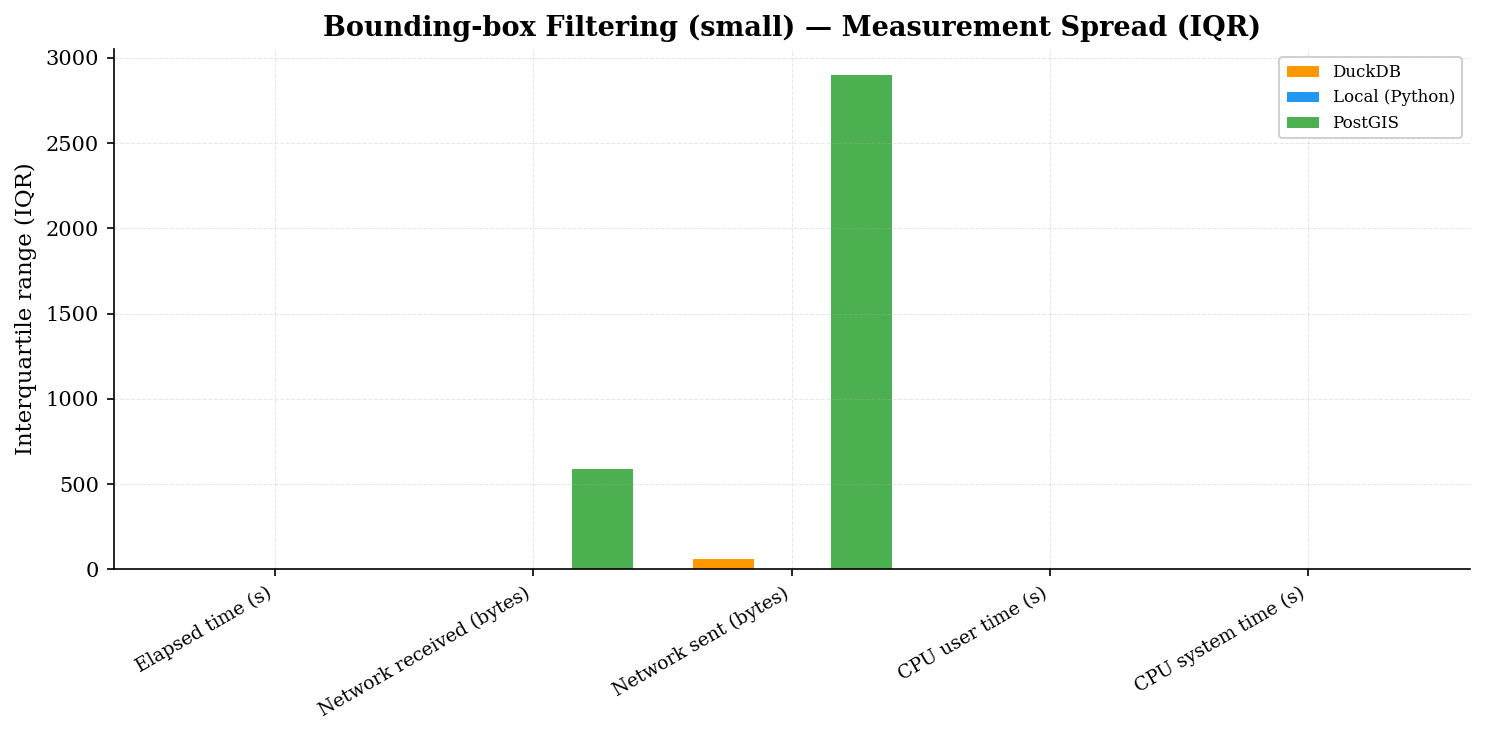

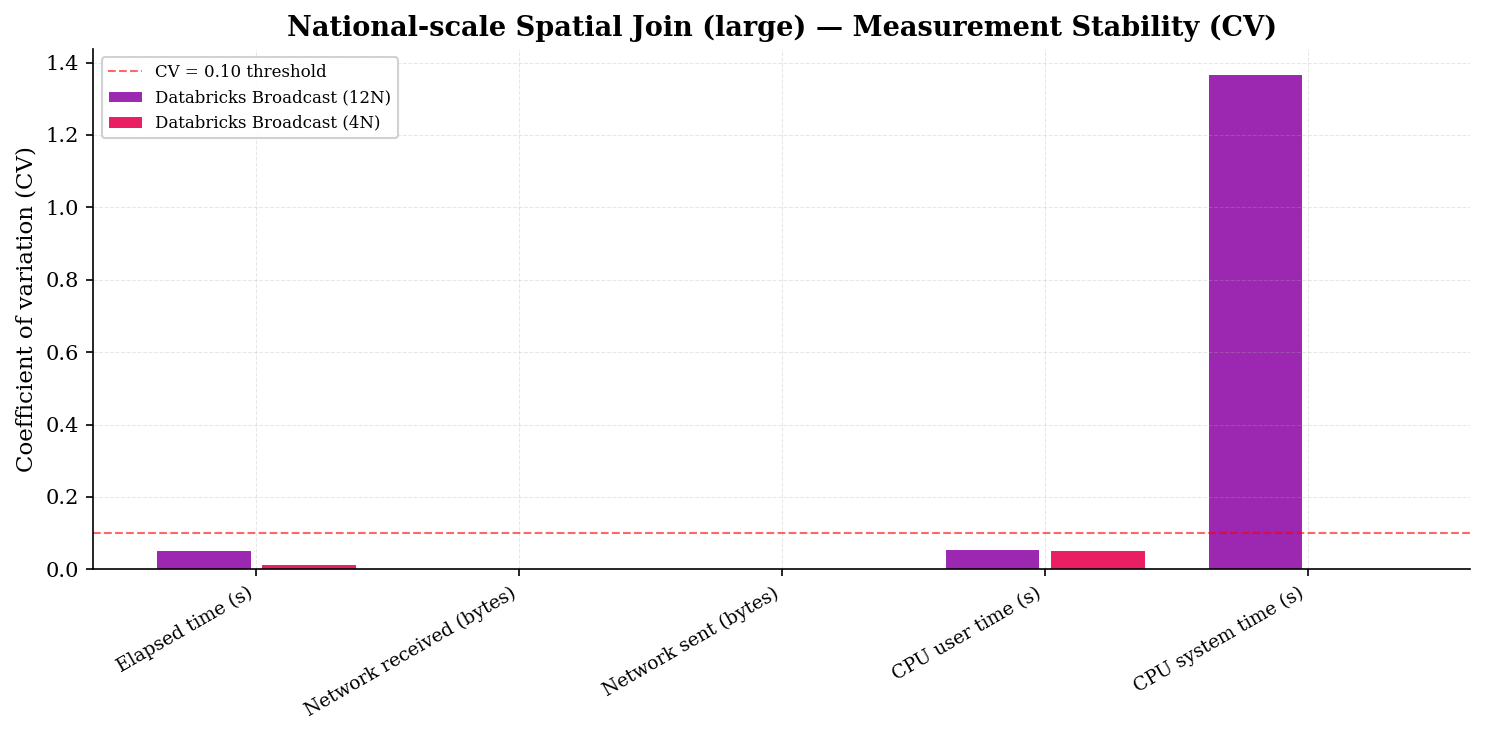

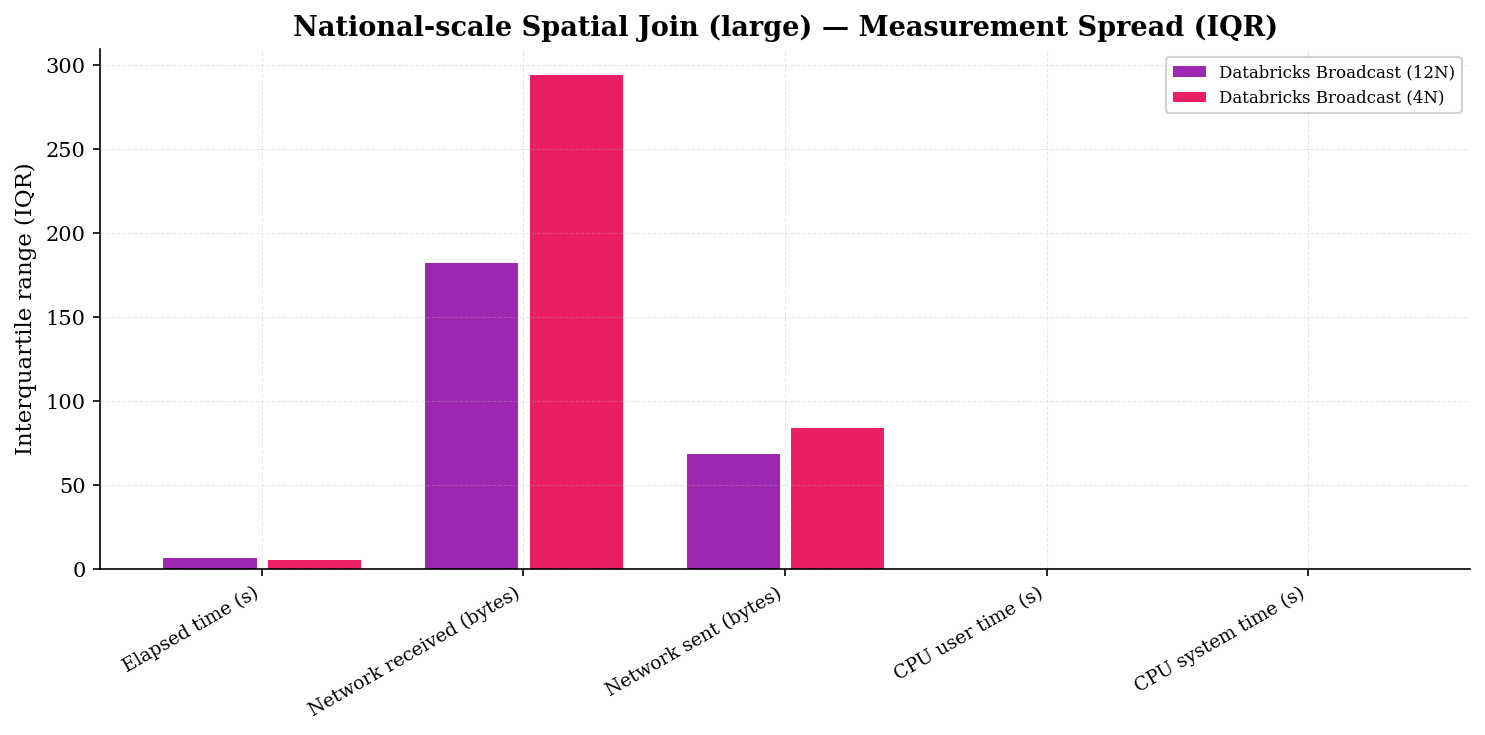

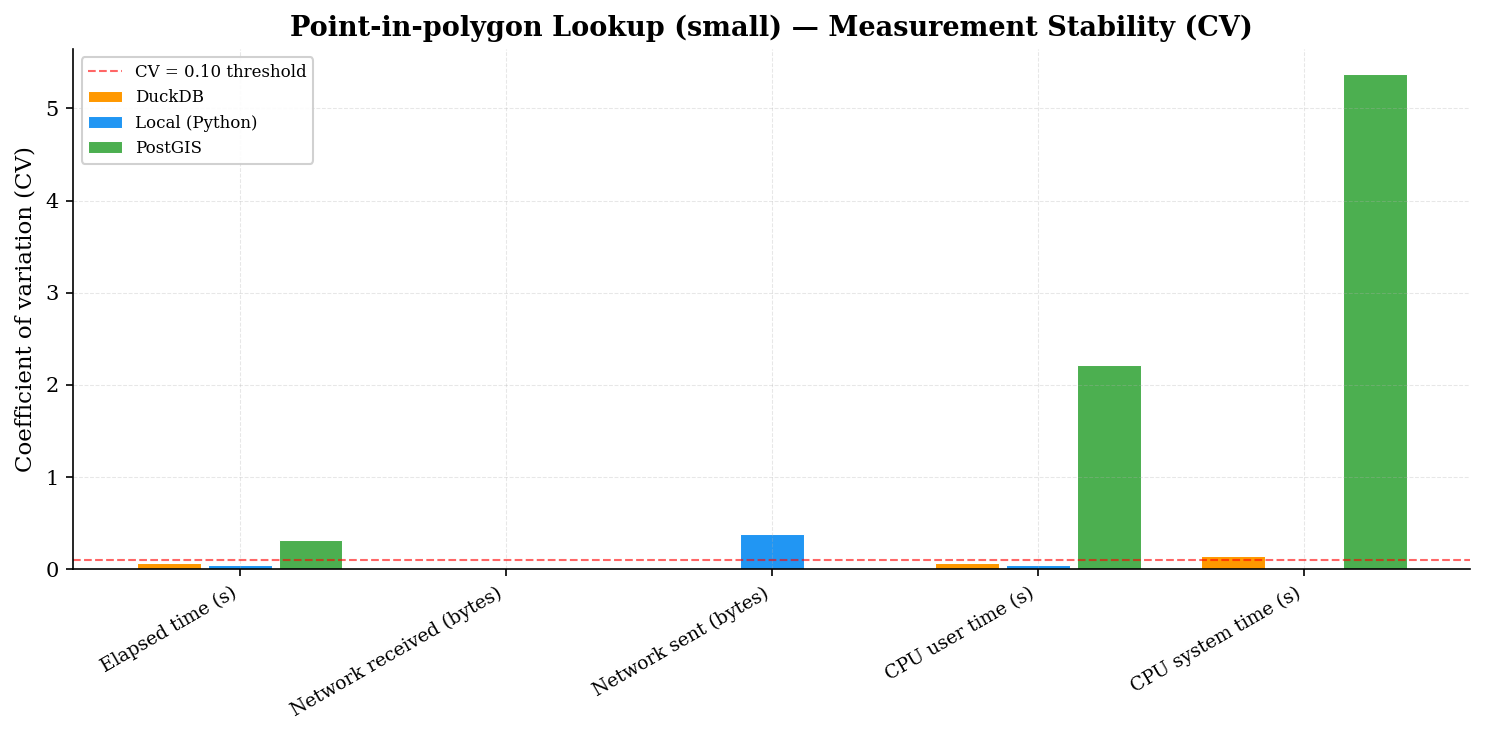

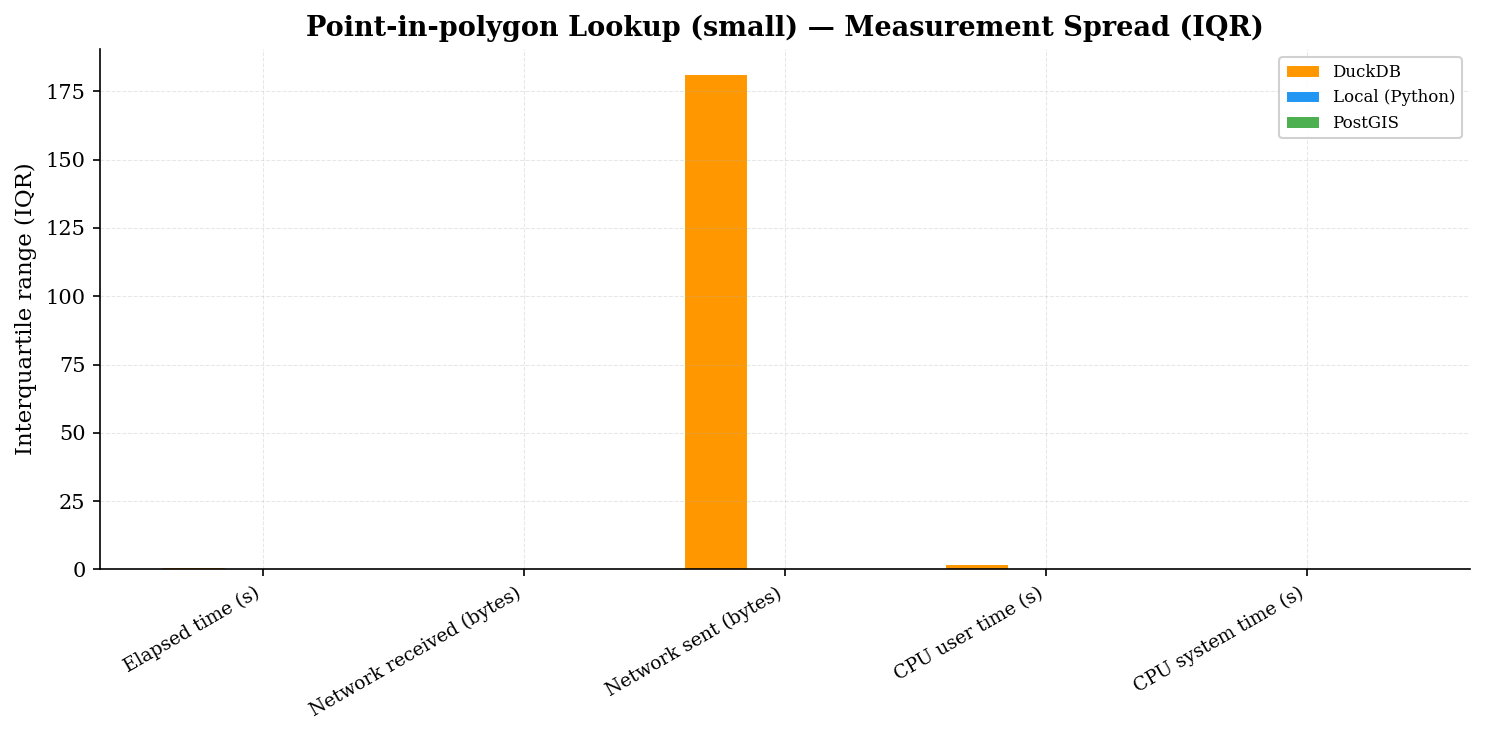

In [30]:
for wt in sorted(successful["workload_type"].unique()):
    for ds in sorted(successful["dataset_size"].unique()):
        mask = (successful["workload_type"] == wt) & (successful["dataset_size"] == ds)
        if not mask.any():
            continue

        data = successful[mask]
        configs = sorted(data["configuration"].unique())
        metrics_to_show = [m for m in PRIMARY_METRICS + AUXILIARY_METRICS if data[m].notna().any()]

        cv_rows = []
        for cfg in configs:
            for metric in metrics_to_show:
                vals = data[data["configuration"] == cfg][metric].dropna().values
                if len(vals) >= 2:
                    mean_val = np.mean(vals)
                    cv = float(np.std(vals, ddof=1) / mean_val) if mean_val > 0 else np.nan
                    iqr = float(np.percentile(vals, 75) - np.percentile(vals, 25))
                    cv_rows.append({"config": cfg, "metric": metric, "cv": cv, "iqr": iqr,
                                    "std": float(np.std(vals, ddof=1)), "n": len(vals)})

        if not cv_rows:
            continue

        cv_df = pd.DataFrame(cv_rows)

        # ── CV bar chart ──
        n_metrics = len(metrics_to_show)
        fig, ax = plt.subplots(figsize=(max(10, 2 * n_metrics), 5))
        x = np.arange(n_metrics)
        cfgs_in_data = [c for c in configs if c in cv_df["config"].values]
        width = 0.8 / max(len(cfgs_in_data), 1)

        for j, cfg in enumerate(cfgs_in_data):
            cvs = []
            for metric in metrics_to_show:
                row = cv_df[(cv_df["config"] == cfg) & (cv_df["metric"] == metric)]
                cvs.append(float(row["cv"].iloc[0]) if len(row) > 0 else 0)
            offset = (j - len(cfgs_in_data) / 2 + 0.5) * width
            ax.bar(x + offset, cvs, width * 0.9, label=_label(cfg), color=_color(cfg),
                   edgecolor="white", linewidth=0.5)

        ax.axhline(y=0.10, color="red", linestyle="--", alpha=0.6, linewidth=1, label="CV = 0.10 threshold")
        ax.set_xticks(x)
        ax.set_xticklabels([_mlabel(m) for m in metrics_to_show], rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Coefficient of variation (CV)")
        ax.set_title(f"{_wlabel(wt)} ({ds}) — Measurement Stability (CV)")
        ax.legend(loc="best", fontsize=8)
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_cv")

        # ── IQR bar chart ──
        fig, ax = plt.subplots(figsize=(max(10, 2 * n_metrics), 5))
        for j, cfg in enumerate(cfgs_in_data):
            iqrs = []
            for metric in metrics_to_show:
                row = cv_df[(cv_df["config"] == cfg) & (cv_df["metric"] == metric)]
                iqrs.append(float(row["iqr"].iloc[0]) if len(row) > 0 else 0)
            offset = (j - len(cfgs_in_data) / 2 + 0.5) * width
            ax.bar(x + offset, iqrs, width * 0.9, label=_label(cfg), color=_color(cfg),
                   edgecolor="white", linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels([_mlabel(m) for m in metrics_to_show], rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Interquartile range (IQR)")
        ax.set_title(f"{_wlabel(wt)} ({ds}) — Measurement Spread (IQR)")
        ax.legend(loc="best", fontsize=8)
        fig.tight_layout()
        _savefig(fig, f"{wt}_{ds}_iqr")

### 9.10 Measurement Stability

The coefficient of variation (CV = std / mean) measures relative dispersion.
Lower CV indicates more stable, repeatable measurements.  Configurations with
CV > 0.10 are flagged with a dashed threshold line — these may warrant
additional benchmark passes before drawing firm conclusions.

## 10. Reporting Tables — LaTeX Export

In [31]:
table1.to_latex(TABLES_DIR / "table1_descriptive_stats.tex", escape=True, float_format="%.4f")
table2.to_latex(TABLES_DIR / "table2_cross_pass.tex", escape=True, float_format="%.4f")

if len(table3) > 0:
    table3.to_latex(TABLES_DIR / "table3_pairwise.tex", escape=True, float_format="%.4f")

if len(table4) > 0:
    t4 = table4.reset_index() if isinstance(table4.index, pd.MultiIndex) else table4
    t4.to_latex(TABLES_DIR / "table4_consistency.tex", escape=True)

if len(rq1_ranking) > 0:
    rq1_ranking.to_latex(TABLES_DIR / "rq1_ranking.tex", escape=True, float_format="%.4f")

print(f"LaTeX tables exported to {TABLES_DIR}/")
for f in sorted(TABLES_DIR.glob("*.tex")):
    print(f"  {f.name}")

LaTeX tables exported to tables/
  rq1_ranking.tex
  table1_descriptive_stats.tex
  table2_cross_pass.tex
  table3_pairwise.tex
  table4_consistency.tex
